Contains the main code for the Reinforcement Learning Models.

Here, a discrete reinforcement learning model is run on a single stock.

Talk about state space, decisions with regards to the return bins and the uninvested_cash
With return bins, (0.9,1.1) or the quantile based style
Uninvested cash is [0,1]. 

With actions, reduce no of actions to 2, i.e just hold or buy/sell for each state to avoid identical actions i.e buy, hold are same with 0 and sell, hold are same with 1 cash fraction.

With regards to the metrics used, the metrics used here are the convergence metrics, all the metrics in standard reinforcement learning along with a discussion of what's occuring with the Q learning changes across the model.

There is also the reward scaling things and the exploring the initialization that doesn't work as well

The next methods involve hyperparameter selection

This test strategy can be generalized across 3 different stocks to see if the particular method selected works.

Also check the double Q-learning model to see if the particular strategy works and if it does work how effective is the actual strategy.





In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import pandas as pd
from pandas import read_csv
import numpy as np
import matplotlib.pyplot as plt
stock_data = read_csv('aapl_msi_sbux.csv')
stock_data = np.array(stock_data)


In [2]:
n_rows = len(stock_data)
n_stocks = len(stock_data[0])
print(n_rows)
print(n_stocks)

1259
3


### Data Randomization Logic

Given the data here is sequential, it made sense to take the data in order.

Here, the data is split 80% for actually training the model and fixing the Q values, then the final 20% is the test set that these Q values are applied to.

In order to compare the train and test portfolios annualization is required, particularly since the train data is likely to run for 4 times as long as the test data.

The portfolios are using the equations below.

### Annualization

Portfolios are annualized for a fair comparison

The standard formula for compounding is:
\begin{equation*}
       P_{T} = P_{0}(1+r)^{T/252}
\end{equation*}

$P_{annual} = P_{0}(1+r)$

Therefore $P_{annual} = P_{0}\left(\frac{P_{T}}{P_{0}}\right)^{252/T}$

In [3]:
def annualization(original, time, principal):
  return np.round(principal*(original/principal)**(252/time),2)

## State Space

A basic state space is chosen since with only 1000 trading days in data, a small state action space is required to make sure the model can actually adapt to the conditions provided.

It is important to note that the chosen states need to repeat across the model and in both the train and test data for the results to be effective

The states chosen are the returns i.e $P_{t}/P_{t-1}$ and the fraction of cash available relative to portfolio amount.

### Returns

For returns there are 10 bins, 8 equally spaced between 0.9-1.1 and then the other 2 are less than 0.9 and greater than 1.1 respectively.

Alternatively, the return bin can also be based on the quantile values of the stock as well.

### Cash Fraction

For the fraction of cash available, this is generally close to 0 or 1 since the actions buy all and sell all are being used, therefore this works as a binary flag.

Note that the rewards are unnormalized. Attempting to normalize them using scaling techniques doesn't have a substantial impact.


In [4]:
import numpy as np

class State_basic:
    def __init__(self, raw_data, uninvested_cash, n_bins, bin_edges,
                 n_cash_bins, cash_bin_edges):
        self.shares = 0
        self.raw_data = raw_data
        self.uninvested_cash = uninvested_cash
        self.n_bins = n_bins
        self.n_cash_bins = n_cash_bins
        # gives 8 intervals of 0.25, one less than 0.9, one greater than 1.1
        self.bin_edges = bin_edges # n_bins-1 edges -> n_bins buckets
        # interior points only (not the range endpoints themselves) so n_cash_bins=2 gives a single
        # edge at the midpoint (e.g. 0.5 for range (0,1)), splitting cleanly into two bins
        self.cash_bin_edges = cash_bin_edges

    def get_real_prices(self, time):
        return self.raw_data[time]

    def get_price_return(self, time):
        # simple gross return: today's price over yesterday's (price[t]/price[t-1]), using only
        # information already known at time t - no look-ahead into price[t+1]
        if time == 0:
            return 1.0  # no prior price on the very first day - treat as "no change"
        return self.raw_data[time] / self.raw_data[time - 1]

    def get_observation(self, time):
        # discretize the price return into a bin index
        return_bin = int(np.digitize(self.get_price_return(time), self.bin_edges))
        # cash as a fraction of the CURRENT total portfolio value (not the starting cash) - this
        # is always in [0, 1] by construction (cash can't exceed the wealth it's part of). Given
        # the all-or-nothing buy/sell design, it's always either ~0 (invested: portfolio value is
        # almost entirely in shares) or exactly 1.0 (in cash: portfolio_value == uninvested_cash),
        # so a single midpoint threshold cleanly separates the two - a genuine binary position flag
        cash_fraction = self.uninvested_cash / self.portfolio_value(time)
        cash_bin = int(np.digitize(cash_fraction, self.cash_bin_edges))
        # observation stays 2D: (return_bin, cash_bin), used directly as a Q-table index
        return (return_bin, cash_bin)

    def portfolio_value(self, time):
        return self.uninvested_cash + self.shares*self.get_real_prices(time)

    def reward(self, a, time):
        # two actions instead of three: buy and sell used to be separate actions, but given the
        # all-or-nothing sizing, one of them was always a no-op identical to hold depending on
        # whether the agent was currently invested (buying while already fully invested, or
        # selling while already fully in cash, both did nothing). Collapsing them into a single
        # state-dependent "trade" action removes that redundancy - every action now has a
        # distinct effect in every state, and the Q-table shrinks from 3 actions to 2.
        prices_now = self.get_real_prices(time)
        portfolio_before = self.uninvested_cash + prices_now * self.shares

        if a == 0:      # trade: buy if currently in cash, sell if currently invested
            if self.shares == 0:
                shares_bought = int(self.uninvested_cash / prices_now)
                self.uninvested_cash -= prices_now * shares_bought
                self.shares += shares_bought
            else:
                self.uninvested_cash += prices_now * self.shares
                self.shares = 0
        # a == 1: hold

        price_next = self.get_real_prices(time + 1)
        portfolio_after = self.uninvested_cash + price_next * self.shares
        # reward scale
        return portfolio_after - portfolio_before

The basic agent class created here.

In [5]:
class Agent_basic:
    def __init__(self, n_bins, n_cash_bins, n_actions=2, eta=0.1, gamma=0.95):
        self.Q = np.zeros((n_bins, n_cash_bins, n_actions))   # indexed by (return_bin, cash_bin, action)
        self.visit_counts = np.zeros((n_bins, n_cash_bins, n_actions), dtype=int)  # for the coverage diagnostic
        self.eta = eta       # step size, alpha
        self.gamma = gamma

    def select_action(self, s):
        return np.argmax(self.Q[s])   # s is a (return_bin, cash_bin) tuple

    def update(self, s, s_next, a, r):
        # standard Q-learning: bootstraps off the MAX over next-state actions (off-policy)
        target = r + self.gamma * np.max(self.Q[s_next])
        self.Q[s][a] = self.Q[s][a] + self.eta * (target - self.Q[s][a])
        self.visit_counts[s][a] += 1

Initially all the models will only be tested on the AAPL stock. 

The model strategy will be tested on different stocks in the Cross Stock Generalization section

In [ ]:
split = int(0.8 * len(stock_data))
train_raw = stock_data[:split, 0]   # column 0 = AAPL, adjust index if using a different stock
test_raw = stock_data[split:, 0]

# here the required bins are created for the state space
n = len(train_raw)
returns = train_raw[1:]/train_raw[:(n-1)]
n_bins = 10
n_actions = 2

intervals = np.linspace(1/n_bins, 1-1/n_bins, n_bins-1)
bin_edges = [np.quantile(returns,intervals[i]) for i in range(len(intervals))]
n_cash_bins = 2
cash_bin_edges = [0.5]

N = 50
initial_cash = 10000

## Setting up Baseline Models before testing the reinforcement learning techniques

### Random Trading Strategy

Note that random trading is dependent on the action space and state space of the reinforcement learning model. 

It can be used to determine whether the reinforcement learning model has actually learnt the required policy

In [ ]:
def run_random(raw, n_bins, n_actions, seed):
    rng = np.random.default_rng(seed)
    state = State_basic(raw, initial_cash, n_bins=n_bins, bin_edges=bin_edges,
                         n_cash_bins=n_cash_bins, cash_bin_edges=cash_bin_edges)
    for t in range(len(raw) - 1):
        a = rng.integers(0, n_actions)
        state.reward(a, t)
    final_value = state.portfolio_value(len(raw) - 1)
    return annualization(final_value, len(raw) - 1, initial_cash)

# average over multiple seeds, since a single random run is noisy
random_train_results = np.array([run_random(train_raw, n_bins, n_actions, seed) for seed in range(N)])
random_test_results = np.array([run_random(test_raw, n_bins, n_actions, seed) for seed in range(N)])

print(f"Random trading -- Train: mean={random_train_results.mean():.2f}, std={random_train_results.std():.2f}")
print(f"Random trading -- Test:  mean={random_test_results.mean():.2f}, std={random_test_results.std():.2f}")

Random trading -- Train: mean=10933.27, std=577.83
Random trading -- Test:  mean=11086.31, std=1181.61


### Buy and Hold Strategy

This strategy is simply buy the stock and hold it for the entire duration of the strategy.

In [9]:
def run_buy_and_hold(raw, initial_cash):
    shares = int(initial_cash / raw[0])
    cash = initial_cash - shares * raw[0]
    final_value = cash + shares * raw[-1]
    return annualization(final_value, len(raw) - 1, initial_cash)

buy_hold_train = run_buy_and_hold(train_raw, initial_cash)
buy_hold_test = run_buy_and_hold(test_raw, initial_cash)

print(f"Buy & hold -- Train: {buy_hold_train:.2f}   Test: {buy_hold_test:.2f}")

Buy & hold -- Train: 11799.70   Test: 12071.51


In [10]:
def run_greedy(raw, agent, n_bins=n_bins, n_cash_bins=n_cash_bins, cash_bin_edges=cash_bin_edges):
    state = State_basic(raw, uninvested_cash=initial_cash, n_bins=n_bins, bin_edges=bin_edges,
                         n_cash_bins=n_cash_bins, cash_bin_edges=cash_bin_edges)
    actions_taken = []
    for t in range(len(raw) - 1):
        s = state.get_observation(t)
        a = agent.select_action(s)
        actions_taken.append(a)
        state.reward(a, t)
    final_value = state.portfolio_value(len(raw) - 1)
    annualized_value = annualization(final_value, len(raw) - 1, initial_cash)
    return annualized_value, actions_taken


def train_and_evaluate_greedy(seed, train_raw, test_raw, episodes=10, n_actions=2, eta=0.1, gamma=0.95,
                        epsilon_start=1.0, epsilon_decay=0.995, epsilon_floor=0.0, bin_edges=bin_edges,
                        cash_bin_edges=cash_bin_edges, n_bins=n_bins, n_cash_bins=n_cash_bins):
    np.random.seed(seed)

    agent = Agent_basic(n_bins=n_bins, n_cash_bins=n_cash_bins, n_actions=n_actions, eta=eta, gamma=gamma)
    train_size = len(train_raw)
    epsilon = epsilon_start
    # one entry PER TRAINING STEP now (not per episode) -- the magnitude of that single
    # (state, action) cell's update, |Q_new[s][a] - Q_old[s][a]|. Every episode's steps
    # get appended back-to-back in training order, so this list ends up length
    # episodes * (train_size - 1) by the end of the whole run. "Max"/"mean" ACROSS
    # SEEDS of this same per-step value is computed later, in the main loop below.
    step_delta_history = []
    policy_flip_history = []  # fraction of states whose greedy action (argmax Q) changed since the previous episode
    episode_reward_history = []  # total (epsilon-greedy) reward earned during each whole training episode
    Q_mean = []
    # actual Q-VALUE magnitude (not its change) at the end of each episode -- checks whether Q is
    # settling into a stable range or drifting off unboundedly, which delta-based checks alone
    # wouldn't catch (small consistently-one-directional updates can still add up to steady growth)
    Q_value_mean_history = []
    Q_value_max_history = []
    # raw per-step REWARD magnitude per episode -- reward = portfolio_after - portfolio_before is
    # the direct environment signal, not a Q estimate, so this is an independent sanity check on
    # top of the Q-value trend above (mean is per-STEP within the episode, not the episode's total
    # -- that's episode_reward_history above; max is the single biggest reward that episode)
    Reward_mean_history = []
    Reward_max_history = []
    first_episode_reward_trace = None  # per-timestep reward within episode 0 (near-random behaviour)
    last_episode_reward_trace = None   # per-timestep reward within the final episode (near-final policy)
    # per-timestep Q.mean()/Q.max() during the same two tracked episodes -- NOT a diagnostic, just
    # a quick informal sanity-check trace (see the standalone plotting cell that uses these, kept
    # separate from run_full_diagnostics on purpose)
    first_episode_q_mean_trace = None
    first_episode_q_max_trace = None
    last_episode_q_mean_trace = None
    last_episode_q_max_trace = None

    for ep in range(episodes):
        Q_before = agent.Q.copy()  # still needed for policy_flip_history, an episode-level (not step-level) comparison
        state = State_basic(train_raw, uninvested_cash=initial_cash, n_bins=n_bins, bin_edges=bin_edges,
                             n_cash_bins=n_cash_bins, cash_bin_edges=cash_bin_edges)
        # only the first and last episode's per-timestep traces are kept in full (for
        # plot_episode_trajectory and the sanity-check plot) -- every other episode just needs its
        # per-episode totals, so we avoid paying the memory cost of a long trace for all `episodes`
        track_trace = (ep == 0) or (ep == episodes - 1)
        reward_trace = [] if track_trace else None
        q_mean_trace = [] if track_trace else None
        q_max_trace = [] if track_trace else None
        episode_reward_total = 0.0
        episode_reward_max = -np.inf
        for t in range(train_size - 1):
            s = state.get_observation(t)
            if np.random.rand() < epsilon:
                a = np.random.randint(agent.Q.shape[-1])   # pulls n_actions from the agent, not a hardcoded 3
            else:
                a = agent.select_action(s)
            r = state.reward(a, t)
            episode_reward_total += r
            episode_reward_max = max(episode_reward_max, r)
            if track_trace:
                reward_trace.append(r)
            s_next = state.get_observation(t + 1)
            q_before_step = agent.Q[s][a]   # only this ONE cell is about to change
            agent.update(s, s_next, a, r)
            step_delta_history.append(abs(agent.Q[s][a] - q_before_step))
            if track_trace:
                q_mean_trace.append(agent.Q.mean())
                q_max_trace.append(agent.Q.max())
        epsilon = max(epsilon * epsilon_decay, epsilon_floor)  # decay stops here, never goes below the floor
        # policy convergence, not value convergence: does the greedy action at each state actually
        # change episode to episode, regardless of how much the underlying Q magnitudes still move
        policy_before = np.argmax(Q_before, axis=-1)
        policy_after = np.argmax(agent.Q, axis=-1)
        policy_flip_history.append(np.mean(policy_before != policy_after))
        Q_mean.append(agent.Q.mean(axis=1).mean(axis=0))
        Q_value_mean_history.append(agent.Q.mean())
        Q_value_max_history.append(agent.Q.max())
        episode_reward_history.append(episode_reward_total)
        Reward_mean_history.append(episode_reward_total / (train_size - 1))
        Reward_max_history.append(episode_reward_max)
        if ep == 0:
            first_episode_reward_trace = reward_trace
            first_episode_q_mean_trace = q_mean_trace
            first_episode_q_max_trace = q_max_trace
        if ep == episodes - 1:
            last_episode_reward_trace = reward_trace
            last_episode_q_mean_trace = q_mean_trace
            last_episode_q_max_trace = q_max_trace

    train_final, train_actions = run_greedy(train_raw, agent, n_bins=n_bins, n_cash_bins=n_cash_bins)
    test_final, test_actions = run_greedy(test_raw, agent, n_bins=n_bins, n_cash_bins=n_cash_bins)

    return (agent, train_final, test_final, step_delta_history, train_actions, test_actions,
            Q_mean, policy_flip_history, episode_reward_history, first_episode_reward_trace, last_episode_reward_trace,
            Q_value_mean_history, Q_value_max_history, Reward_mean_history, Reward_max_history,
            first_episode_q_mean_trace, first_episode_q_max_trace, last_episode_q_mean_trace, last_episode_q_max_trace)

Below is a test run for Q learning before entering into hyperparameter selection

In [11]:
N = 50
episodes = 100
eta = 0.01
gamma = 0.95
epsilon = 1.0
epsilon_decay = 0.95
epsilon_floor = 0.1
initial_cash = 10000


In [ ]:
train_results = np.zeros(N)
test_results = np.zeros(N)
seed_agents = []             # every seed's trained agent, for coverage / policy-stability diagnostics
all_step_delta_history = []  # every seed's per-training-step delta curve -- mean/max ACROSS SEEDS computed below
all_test_actions = []        # every seed's greedy test rollout, for the action-distribution diagnostic
all_policy_flip_history = []  # every seed's per-episode action-flip fraction, averaged for the convergence diagnostic
all_episode_reward_history = []      # every seed's per-episode total training reward, averaged for the reward curve
all_first_episode_reward_trace = []  # every seed's episode-0 per-timestep reward trace, averaged for the within-episode plot
all_last_episode_reward_trace = []   # every seed's final-episode per-timestep reward trace, averaged for the within-episode plot
all_Q_value_mean_history = []  # every seed's per-episode mean-Q-value curve, averaged for the Q-value-magnitude plot
all_Q_value_max_history = []   # every seed's per-episode max-Q-value curve, averaged for the Q-value-magnitude plot
all_Reward_mean_history = []   # every seed's per-episode mean-reward-per-step curve, averaged for the reward-magnitude plot
all_Reward_max_history = []    # every seed's per-episode max-reward curve, averaged for the reward-magnitude plot
all_first_episode_q_mean_trace = []  # every seed's episode-0 per-timestep Q-mean trace, for the sanity-check plot
all_first_episode_q_max_trace = []   # every seed's episode-0 per-timestep Q-max trace, for the sanity-check plot
all_last_episode_q_mean_trace = []   # every seed's final-episode per-timestep Q-mean trace, for the sanity-check plot
all_last_episode_q_max_trace = []    # every seed's final-episode per-timestep Q-max trace, for the sanity-check plot
Q_mean_values = []
for seed in range(N):
    (agent, train_final, test_final, step_delta_history, train_actions, test_actions,
     Q_mean, policy_flip_history, episode_reward_history, first_episode_reward_trace, last_episode_reward_trace,
     Q_value_mean_history, Q_value_max_history, Reward_mean_history, Reward_max_history,
     first_episode_q_mean_trace, first_episode_q_max_trace, last_episode_q_mean_trace, last_episode_q_max_trace) = train_and_evaluate_greedy(
        seed, train_raw, test_raw, episodes=episodes, n_bins=n_bins, n_actions=n_actions, eta=eta, gamma=gamma,
        epsilon_start=epsilon, epsilon_decay=epsilon_decay, epsilon_floor = epsilon_floor, bin_edges=bin_edges,
        n_cash_bins=n_cash_bins, cash_bin_edges=cash_bin_edges)
    train_results[seed] = train_final
    test_results[seed] = test_final
    seed_agents.append(agent)
    all_step_delta_history.append(step_delta_history)
    all_test_actions.append(test_actions)
    all_policy_flip_history.append(policy_flip_history)
    all_episode_reward_history.append(episode_reward_history)
    all_first_episode_reward_trace.append(first_episode_reward_trace)
    all_last_episode_reward_trace.append(last_episode_reward_trace)
    all_Q_value_mean_history.append(Q_value_mean_history)
    all_Q_value_max_history.append(Q_value_max_history)
    all_Reward_mean_history.append(Reward_mean_history)
    all_Reward_max_history.append(Reward_max_history)
    all_first_episode_q_mean_trace.append(first_episode_q_mean_trace)
    all_first_episode_q_max_trace.append(first_episode_q_max_trace)
    all_last_episode_q_mean_trace.append(last_episode_q_mean_trace)
    all_last_episode_q_max_trace.append(last_episode_q_max_trace)
    Q_mean_values.append(Q_mean)

# same variable names as before (avg_delta_history_max/mean) so nothing downstream (the
# diagnostics call below) needs to change -- just what they now mean: per TRAINING STEP,
# aggregated across seeds, instead of per episode, aggregated across the whole Q-table
avg_delta_history_mean = np.mean(all_step_delta_history, axis=0)  # mean across seeds, per training step
avg_delta_history_max = np.max(all_step_delta_history, axis=0)    # max across seeds, per training step
avg_policy_flip_history = np.mean(all_policy_flip_history, axis=0)
avg_episode_reward_history = np.mean(all_episode_reward_history, axis=0)
avg_first_episode_reward_trace = np.mean(all_first_episode_reward_trace, axis=0)
avg_last_episode_reward_trace = np.mean(all_last_episode_reward_trace, axis=0)
avg_Q_value_mean_history = np.mean(all_Q_value_mean_history, axis=0)  # mean across seeds, per episode
avg_Q_value_max_history = np.mean(all_Q_value_max_history, axis=0)    # mean across seeds, per episode
avg_Reward_mean_history = np.mean(all_Reward_mean_history, axis=0)    # mean across seeds, per episode
avg_Reward_max_history = np.mean(all_Reward_max_history, axis=0)      # mean across seeds, per episode
avg_first_episode_q_mean_trace = np.mean(all_first_episode_q_mean_trace, axis=0)  # mean across seeds, per timestep
avg_first_episode_q_max_trace = np.mean(all_first_episode_q_max_trace, axis=0)    # mean across seeds, per timestep
avg_last_episode_q_mean_trace = np.mean(all_last_episode_q_mean_trace, axis=0)    # mean across seeds, per timestep
avg_last_episode_q_max_trace = np.mean(all_last_episode_q_max_trace, axis=0)      # mean across seeds, per timestep
avg_Q_mean = np.mean(Q_mean_values, axis=0)
avg_visit_counts = np.mean([agent.visit_counts for agent in seed_agents], axis=0)

print(f"Episodes = {episodes}")
print(f"Q-learning (greedy) -- Train: mean={train_results.mean():.2f}, std={train_results.std():.2f}")
print(f"Q-learning (greedy) -- Test:  mean={test_results.mean():.2f}, std={test_results.std():.2f}")


Episodes = 100
Q-learning (greedy) -- Train: mean=12289.07, std=344.68
Q-learning (greedy) -- Test:  mean=11876.25, std=746.21


DIAGNOSTIC CHECKLIST
[Train/Test] Train -- mean: 12289.07  std: 344.68
[Train/Test] Test  -- mean: 11876.25  std: 746.21

[Coverage] Unvisited (state, action) pairs: 0 / 40 (0.0%)



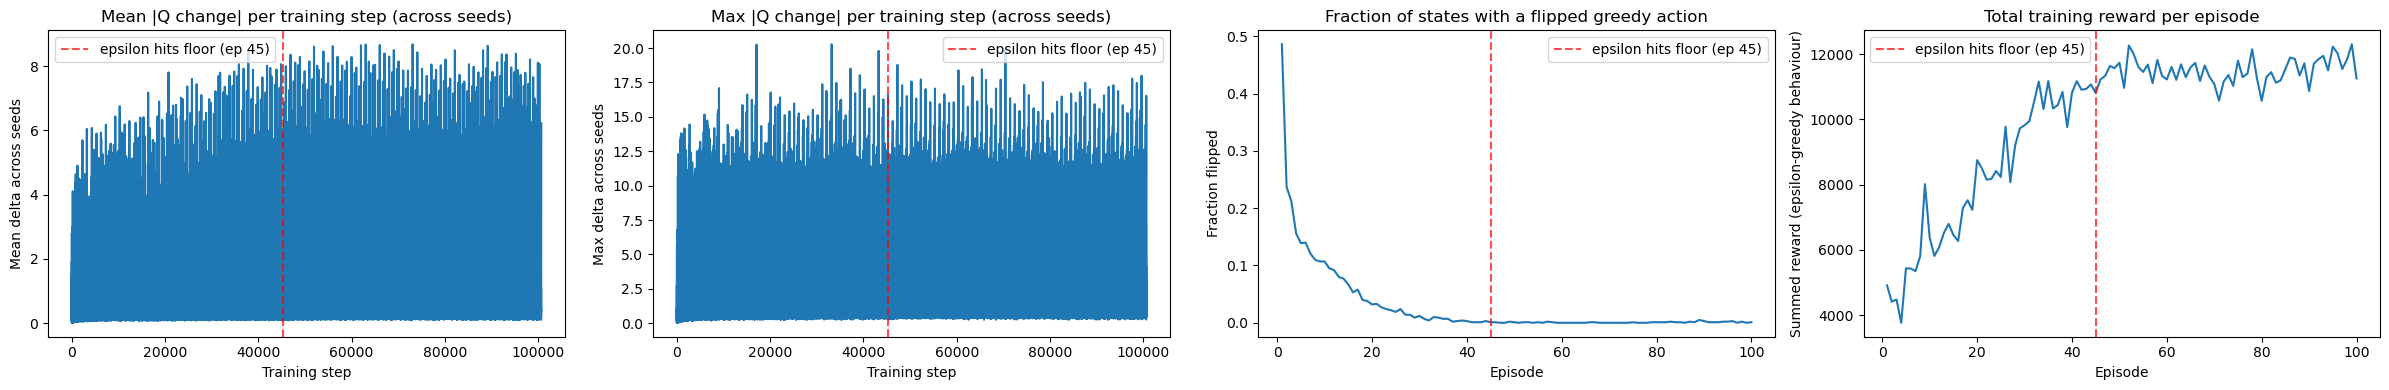

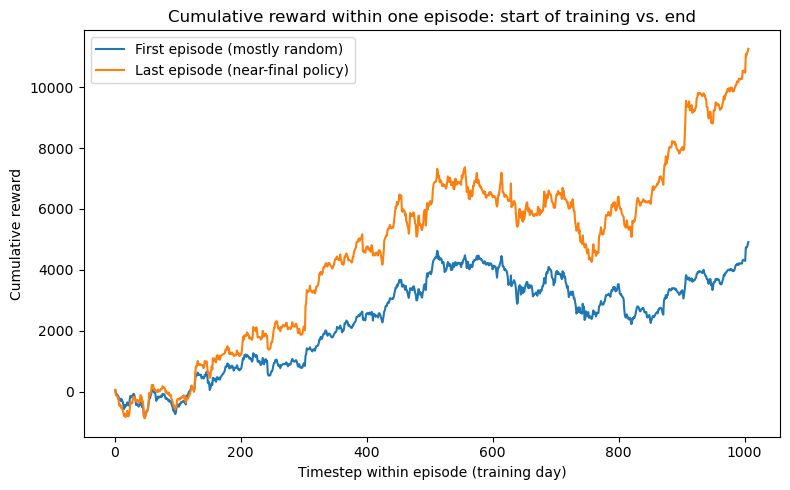

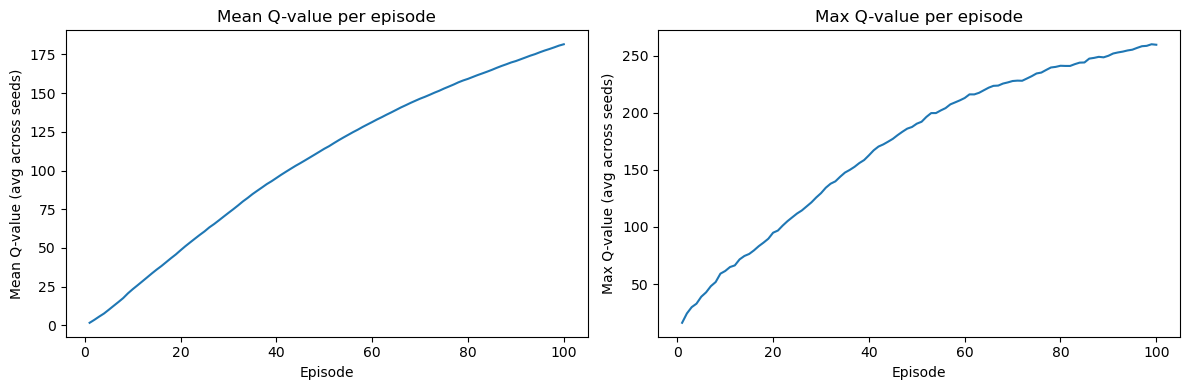

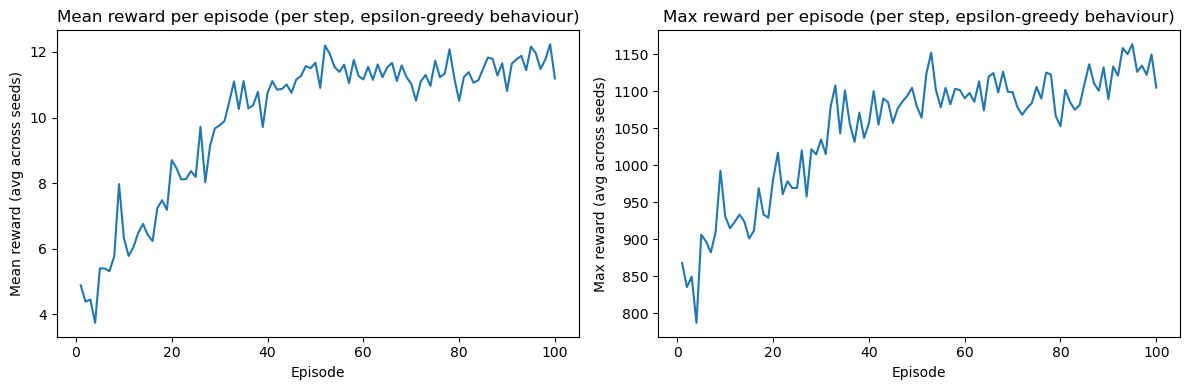


[Policy stability] States checked: 20/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 20 states -- mean: 82.5%  min: 58.0%  max: 100.0%

[State/action summary] 20/20 total states had >= 100 average visits across seeds
 state  avg_visits  majority_action  agreement_pct  mean_Q_majority_action
(4, 0)      6392.1                1          100.0                247.0173
(2, 0)      6137.8                0           58.0                185.8799
(9, 0)      6130.5                1           92.0                221.0841
(8, 0)      6112.0                1           92.0                223.5735
(7, 0)      5996.1                1           96.0                226.9149
(6, 0)      5969.0                0           88.0                195.1087
(3, 0)      5916.9                0           66.0                186.7278
(1, 0)      5847.0                1           64.0                193.7957
(5, 0)      5841.1

In [ ]:
from diagnostics import run_full_diagnostics

run_full_diagnostics(
    visit_counts=avg_visit_counts,
    delta_history=avg_delta_history_max,
    delta_history_mean=avg_delta_history_mean,
    seed_agents=seed_agents,
    greedy_actions=all_test_actions,
    n_actions=n_actions,
    epsilon_start=epsilon,
    epsilon_decay=epsilon_decay,
    epsilon_floor=epsilon_floor,
    train_results=train_results,
    test_results=test_results,
    policy_flip_history=avg_policy_flip_history,
    episode_reward_history=avg_episode_reward_history,
    first_episode_reward_trace=avg_first_episode_reward_trace,
    last_episode_reward_trace=avg_last_episode_reward_trace,
    q_mean_history=avg_Q_value_mean_history,
    q_max_history=avg_Q_value_max_history,
    reward_mean_history=avg_Reward_mean_history,
    reward_max_history=avg_Reward_max_history,
)

Hyperparameter choosing. 

Here Hyperparameters are adjusted for the Q-learning model by considering convergence alongside the validation values outputed by the model.

In [14]:
# further split train_raw into an inner train/validation split, so hyperparameters
# are chosen without the search ever seeing the true held-out test_raw
hp_split = int(0.8 * len(train_raw))
hp_train_raw = train_raw[:hp_split]
hp_val_raw = train_raw[hp_split:]

print(f"Hyperparameter tuning -- inner train: {len(hp_train_raw)} days, inner validation: {len(hp_val_raw)} days")

Hyperparameter tuning -- inner train: 805 days, inner validation: 202 days


In [16]:
eta_grid = [0.001, 0.01]
gamma_grid = [0.95, 0.99, 0.995]

In [ ]:
def grid_search_hyperparameters(train_fn, eta_grid, gamma_grid, N=N, episodes=episodes,
                                  epsilon_start=epsilon, epsilon_decay=epsilon_decay, epsilon_floor=epsilon_floor,
                                  run_diagnostics=False):
    
    rows = []
    for eta_try in eta_grid:
        for gamma_try in gamma_grid:
            train_scores = np.zeros(N)
            val_scores = np.zeros(N)
            seed_agents = []
            all_step_delta_history = []
            all_val_actions = []
            all_policy_flip_history = []
            all_episode_reward_history = []
            all_first_episode_reward_trace = []
            all_last_episode_reward_trace = []
            all_Q_value_mean_history = []
            all_Q_value_max_history = []
            all_Reward_mean_history = []
            all_Reward_max_history = []
            Q_mean_values = []
            all_first_episode_q_mean_trace = []
            all_first_episode_q_max_trace = []
            all_last_episode_q_mean_trace = []
            all_last_episode_q_max_trace = []
            for seed in range(N):
                (agent, train_final, val_final, step_delta_history, train_actions, val_actions,
                 Q_mean, policy_flip_history, episode_reward_history, first_episode_reward_trace, last_episode_reward_trace,
                 Q_value_mean_history, Q_value_max_history, Reward_mean_history, Reward_max_history,
                 first_episode_q_mean_trace, first_episode_q_max_trace, last_episode_q_mean_trace, last_episode_q_max_trace) = train_fn(
                    seed, hp_train_raw, hp_val_raw, episodes=episodes,
                    n_bins=n_bins, n_actions=n_actions, eta=eta_try, gamma=gamma_try,
                    epsilon_start=epsilon_start, epsilon_decay=epsilon_decay, epsilon_floor=epsilon_floor,
                    bin_edges=bin_edges, n_cash_bins=n_cash_bins, cash_bin_edges=cash_bin_edges)
                train_scores[seed] = train_final
                val_scores[seed] = val_final
                seed_agents.append(agent)
                all_step_delta_history.append(step_delta_history)
                all_val_actions.append(val_actions)
                all_policy_flip_history.append(policy_flip_history)
                all_episode_reward_history.append(episode_reward_history)
                all_first_episode_reward_trace.append(first_episode_reward_trace)
                all_last_episode_reward_trace.append(last_episode_reward_trace)
                all_Q_value_mean_history.append(Q_value_mean_history)
                all_Q_value_max_history.append(Q_value_max_history)
                all_Reward_mean_history.append(Reward_mean_history)
                all_Reward_max_history.append(Reward_max_history)
                Q_mean_values.append(Q_mean)
                all_first_episode_q_mean_trace.append(first_episode_q_mean_trace)
                all_first_episode_q_max_trace.append(first_episode_q_max_trace)
                all_last_episode_q_mean_trace.append(last_episode_q_mean_trace)
                all_last_episode_q_max_trace.append(last_episode_q_max_trace)
            rows.append({"eta": eta_try, "gamma": gamma_try,
                         "train_mean": train_scores.mean(), "train_std": train_scores.std(),
                         "val_mean": val_scores.mean(), "val_std": val_scores.std()})

            if run_diagnostics:
                print(f"\n--- eta={eta_try}, gamma={gamma_try} ---")
                run_full_diagnostics(
                    visit_counts=np.mean([a.visit_counts for a in seed_agents], axis=0),
                    delta_history=np.max(all_step_delta_history, axis=0),
                    delta_history_mean=np.mean(all_step_delta_history, axis=0),
                    seed_agents=seed_agents,
                    greedy_actions=all_val_actions,
                    n_actions=n_actions,
                    epsilon_start=epsilon_start,
                    epsilon_decay=epsilon_decay,
                    epsilon_floor=epsilon_floor,
                    train_results=train_scores,
                    test_results=val_scores,
                    policy_flip_history=np.mean(all_policy_flip_history, axis=0),
                    episode_reward_history=np.mean(all_episode_reward_history, axis=0),
                    first_episode_reward_trace=np.mean(all_first_episode_reward_trace, axis=0),
                    last_episode_reward_trace=np.mean(all_last_episode_reward_trace, axis=0),
                    q_mean_history=np.mean(all_Q_value_mean_history, axis=0),
                    q_max_history=np.mean(all_Q_value_max_history, axis=0),
                    reward_mean_history=np.mean(all_Reward_mean_history, axis=0),
                    reward_max_history=np.mean(all_Reward_max_history, axis=0),
                )
    return pd.DataFrame(rows).sort_values("val_mean", ascending=False).reset_index(drop=True)




--- eta=0.001, gamma=0.95 ---
DIAGNOSTIC CHECKLIST
[Train/Test] Train -- mean: 12279.36  std: 452.07
[Train/Test] Test  -- mean: 11544.48  std: 998.86

[Coverage] Unvisited (state, action) pairs: 0 / 40 (0.0%)



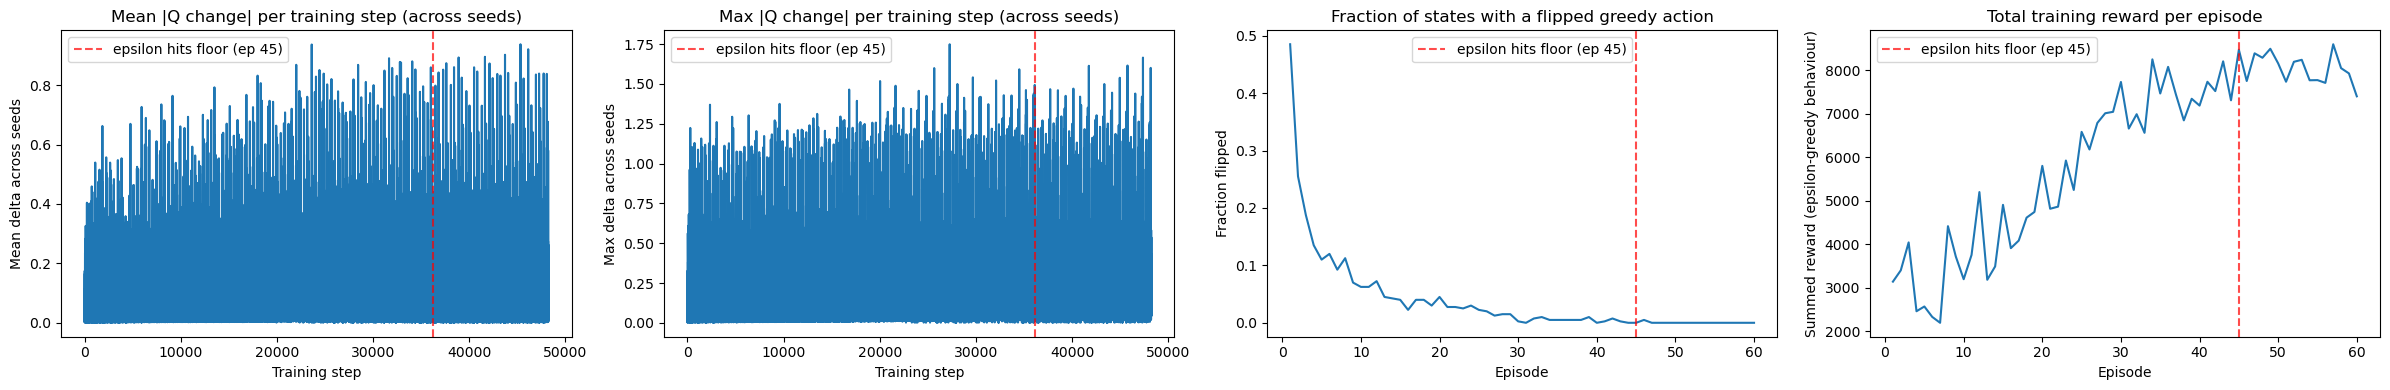

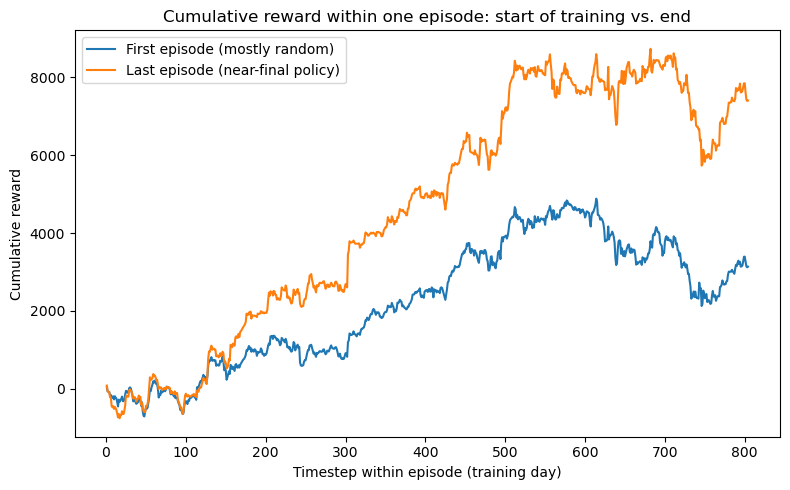

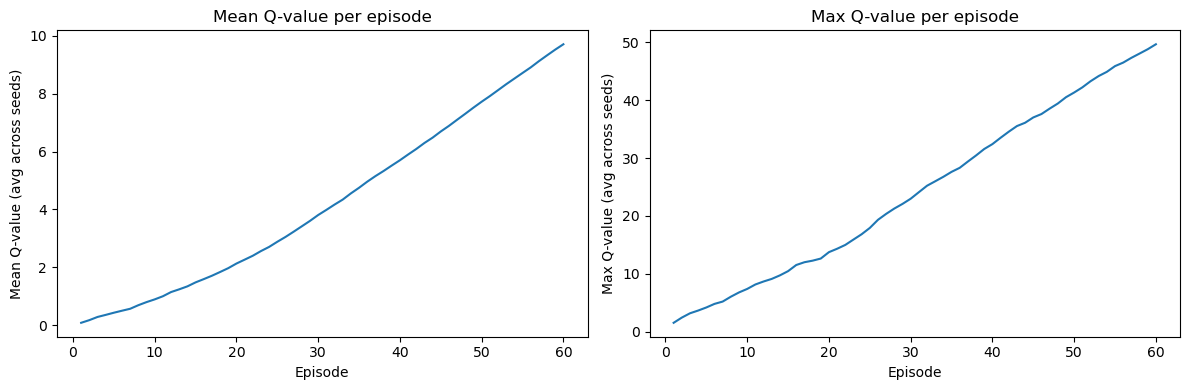

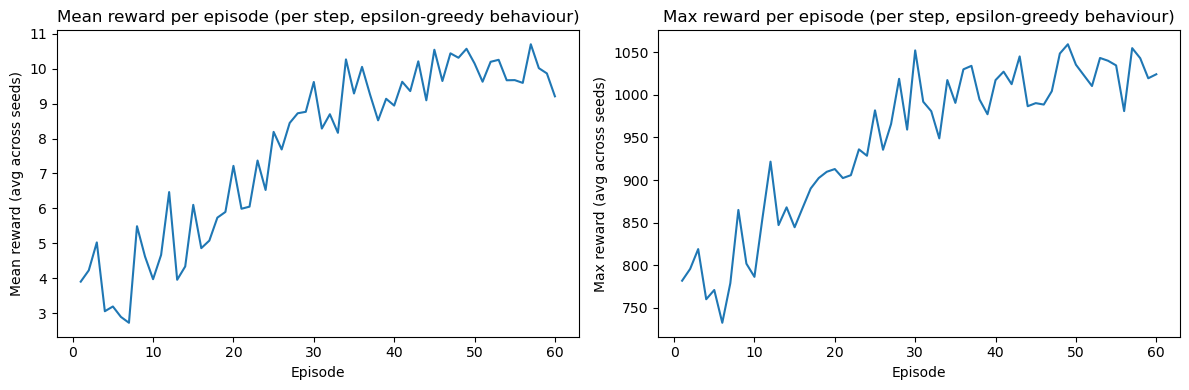


[Policy stability] States checked: 20/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 20 states -- mean: 79.2%  min: 55.0%  max: 100.0%

[State/action summary] 20/20 total states had >= 100 average visits across seeds
 state  avg_visits  majority_action  agreement_pct  mean_Q_majority_action
(9, 0)      3043.8                1           90.0                 18.3068
(0, 1)      2785.6                1           60.0                  6.4502
(8, 0)      2706.1                0           60.0                  7.2784
(3, 0)      2636.6                0          100.0                 11.5886
(2, 0)      2617.3                0           70.0                  8.1321
(1, 0)      2597.7                1           65.0                 11.1212
(0, 0)      2554.4                0           60.0                  5.9903
(7, 0)      2505.3                1           55.0                 17.8034
(1, 1)      2442.3

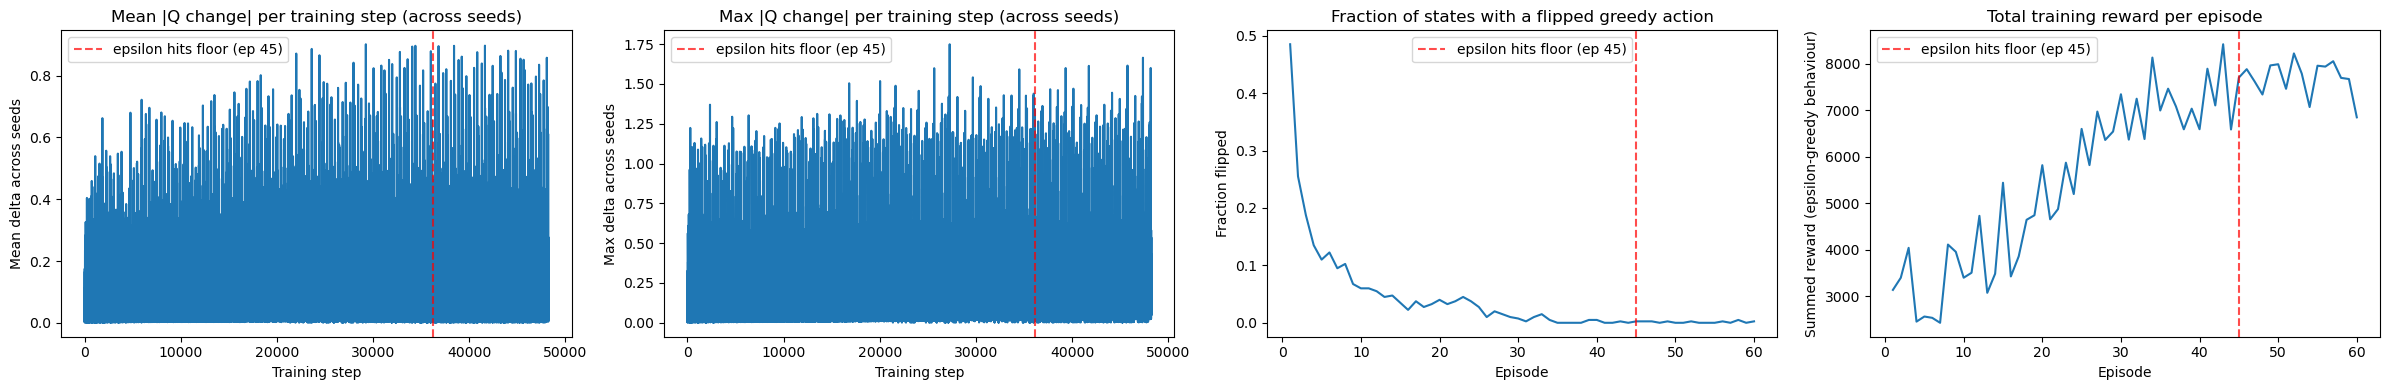

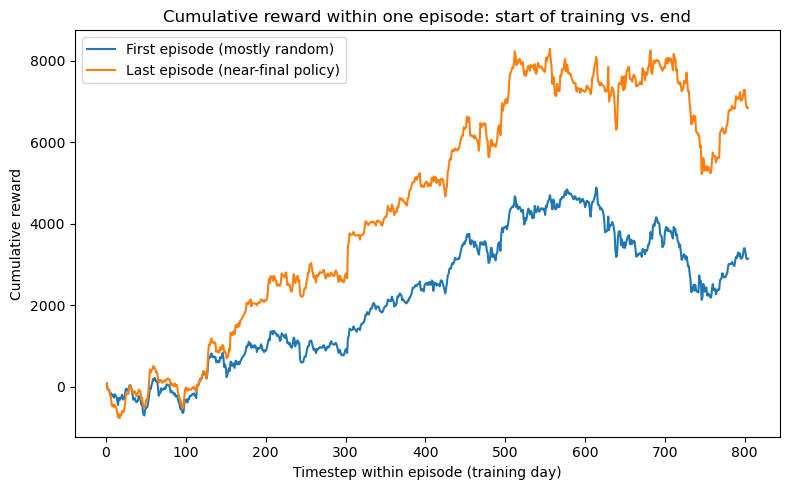

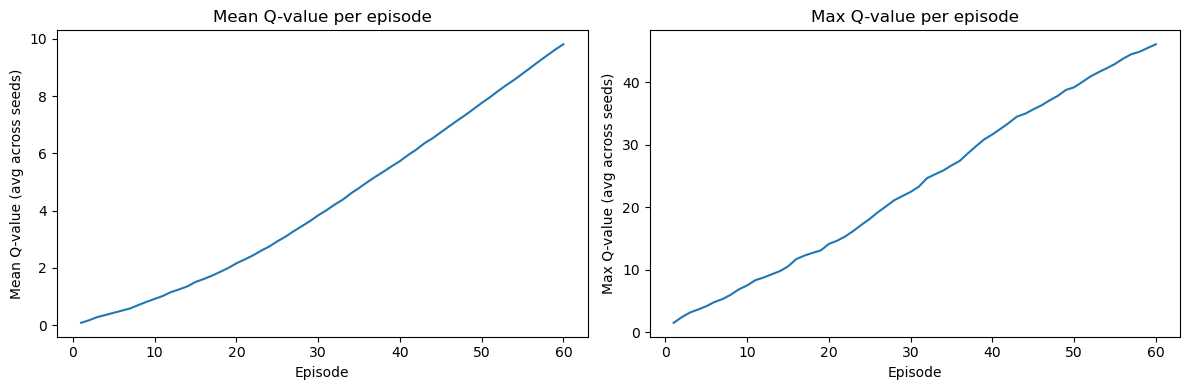

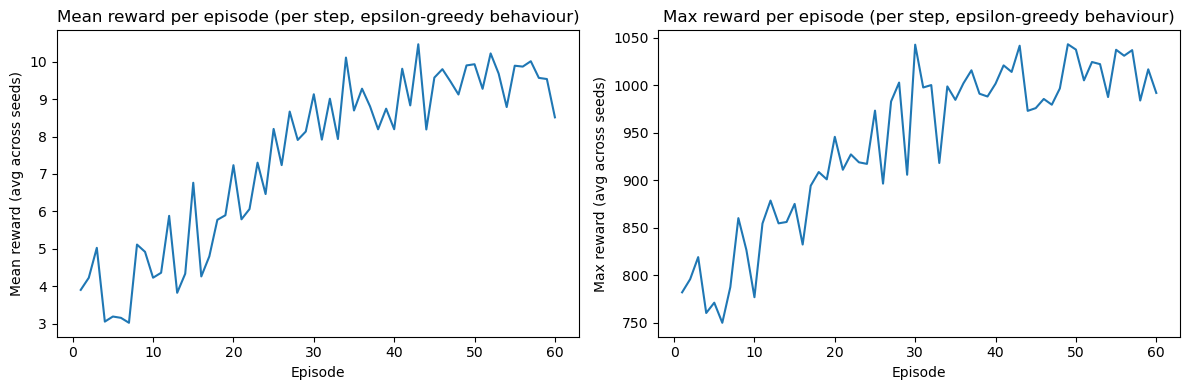


[Policy stability] States checked: 20/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 20 states -- mean: 79.2%  min: 50.0%  max: 100.0%

[State/action summary] 20/20 total states had >= 100 average visits across seeds
 state  avg_visits  majority_action  agreement_pct  mean_Q_majority_action
(9, 0)      3069.1                1           90.0                 18.9466
(0, 1)      2733.9                1           75.0                  7.5657
(8, 0)      2730.2                0           70.0                  8.4469
(3, 0)      2675.9                0          100.0                 11.8310
(1, 0)      2647.5                1           65.0                 13.0241
(2, 0)      2646.2                0           50.0                  6.7656
(0, 0)      2606.1                0           55.0                  5.6273
(7, 0)      2535.6                1           55.0                 17.5374
(6, 0)      2474.0

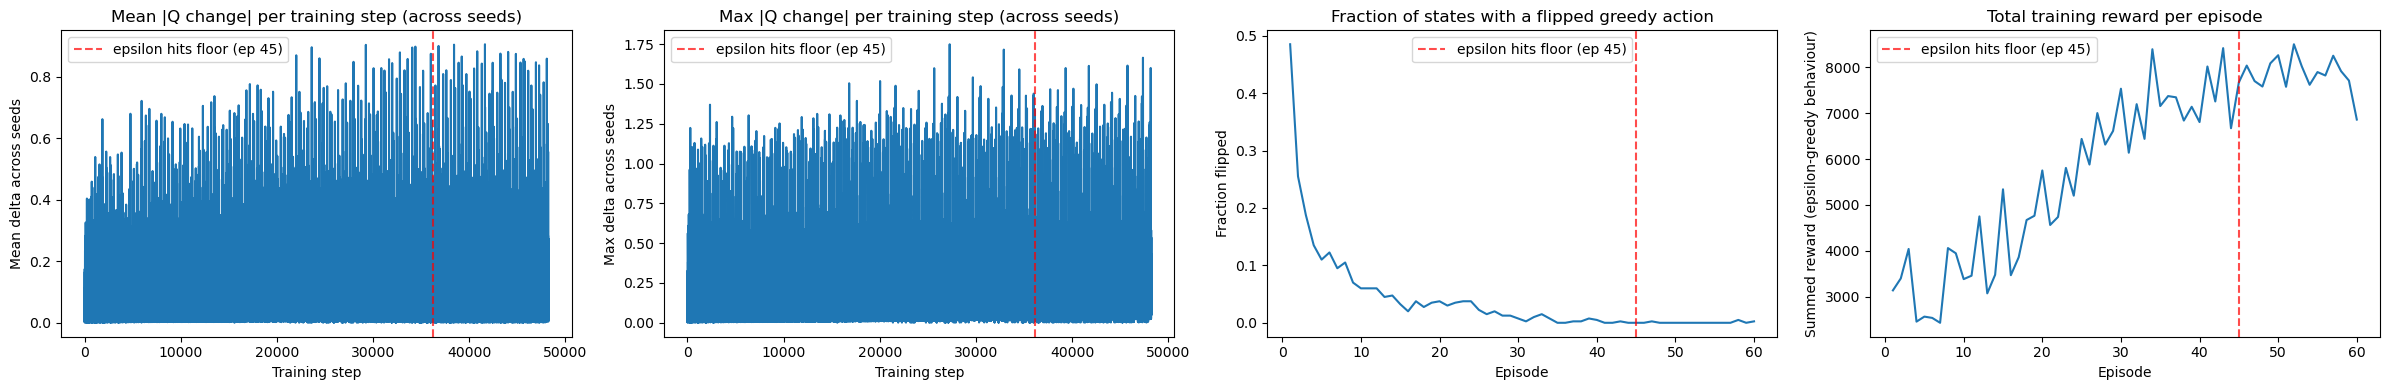

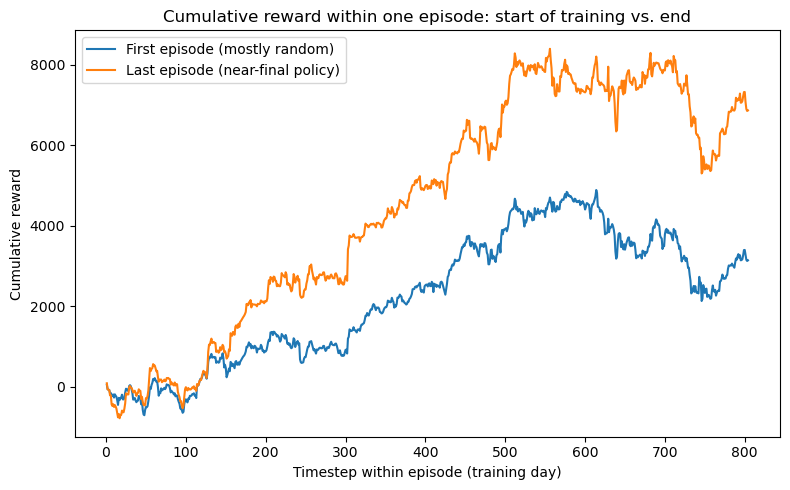

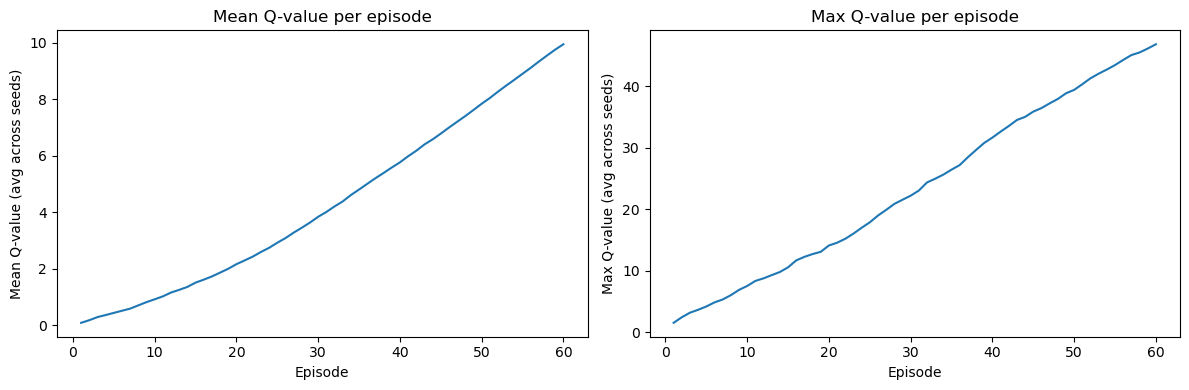

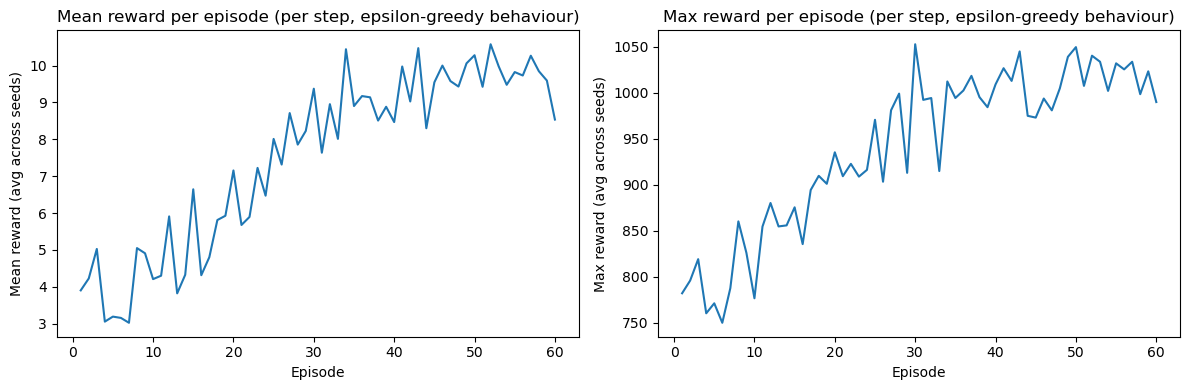


[Policy stability] States checked: 20/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 20 states -- mean: 78.8%  min: 50.0%  max: 100.0%

[State/action summary] 20/20 total states had >= 100 average visits across seeds
 state  avg_visits  majority_action  agreement_pct  mean_Q_majority_action
(9, 0)      3069.4                1           90.0                 18.9574
(0, 1)      2736.8                1           75.0                  7.6833
(8, 0)      2736.4                0           70.0                  8.5694
(3, 0)      2674.9                0          100.0                 11.9841
(1, 0)      2646.4                1           70.0                 13.6704
(2, 0)      2645.2                0           50.0                  6.9317
(0, 0)      2603.1                0           50.0                  5.7029
(7, 0)      2531.7                1           55.0                 17.6914
(6, 0)      2476.4

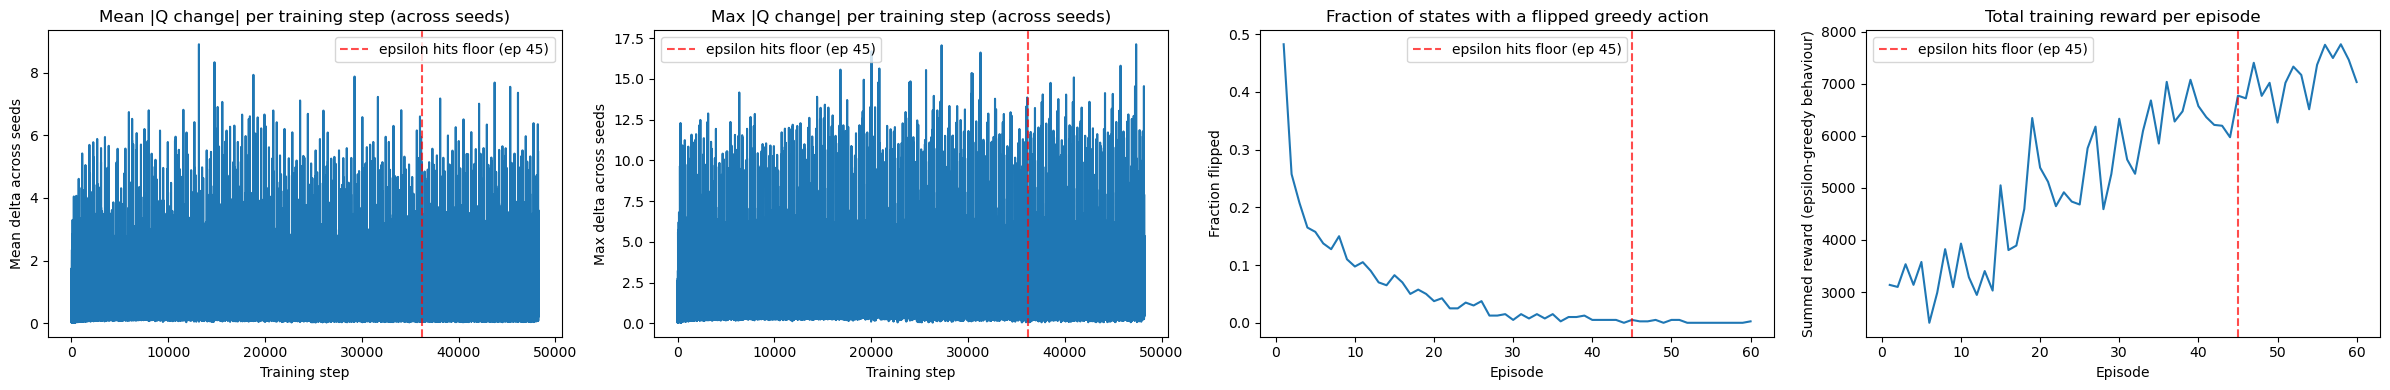

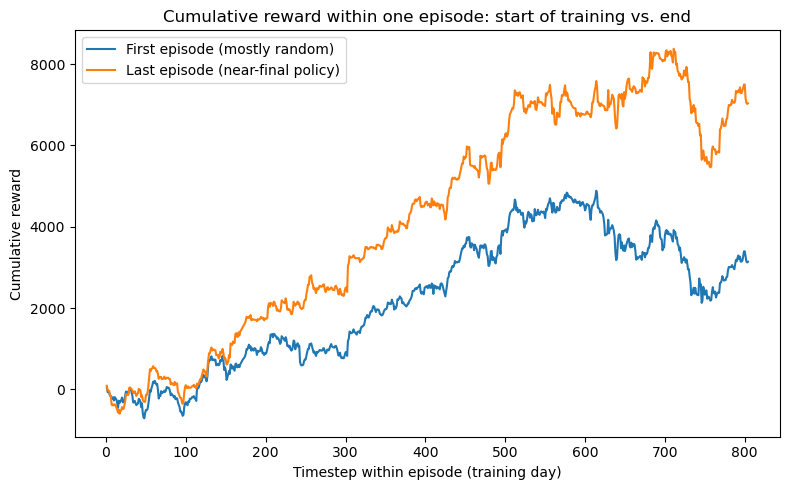

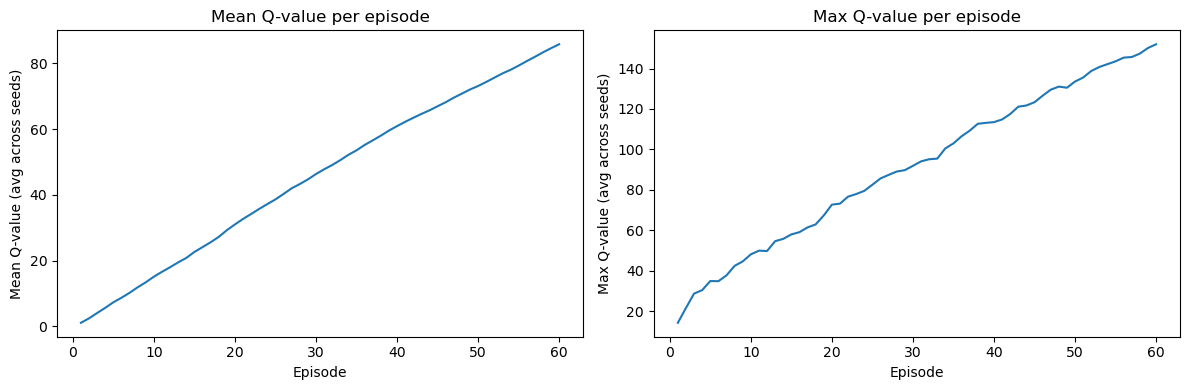

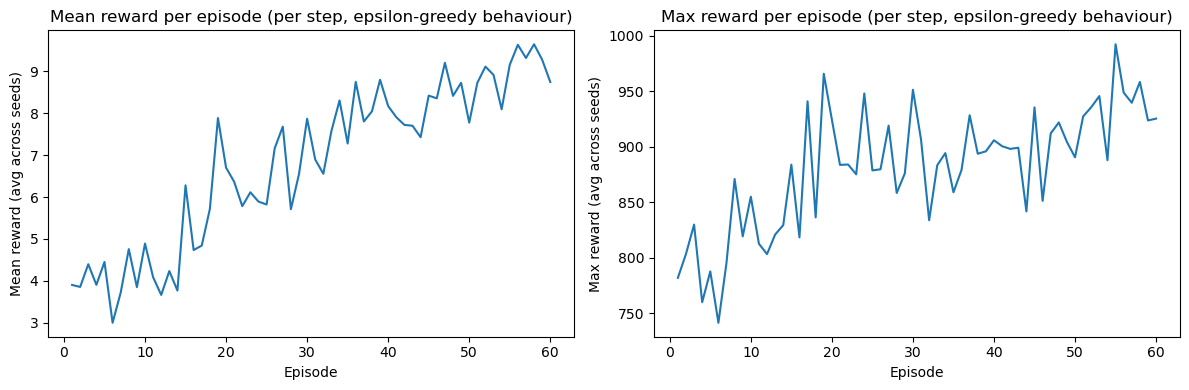


[Policy stability] States checked: 20/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 20 states -- mean: 82.2%  min: 55.0%  max: 100.0%

[State/action summary] 20/20 total states had >= 100 average visits across seeds
 state  avg_visits  majority_action  agreement_pct  mean_Q_majority_action
(0, 1)      3046.1                1           90.0                 97.7206
(9, 0)      2727.9                0           65.0                 91.6356
(8, 1)      2693.2                1           95.0                101.0542
(9, 1)      2672.0                0          100.0                126.2651
(1, 1)      2654.9                0           90.0                130.9012
(3, 1)      2512.3                1          100.0                104.4560
(2, 1)      2425.8                1          100.0                106.1040
(3, 0)      2407.7                0          100.0                104.4423
(8, 0)      2406.8

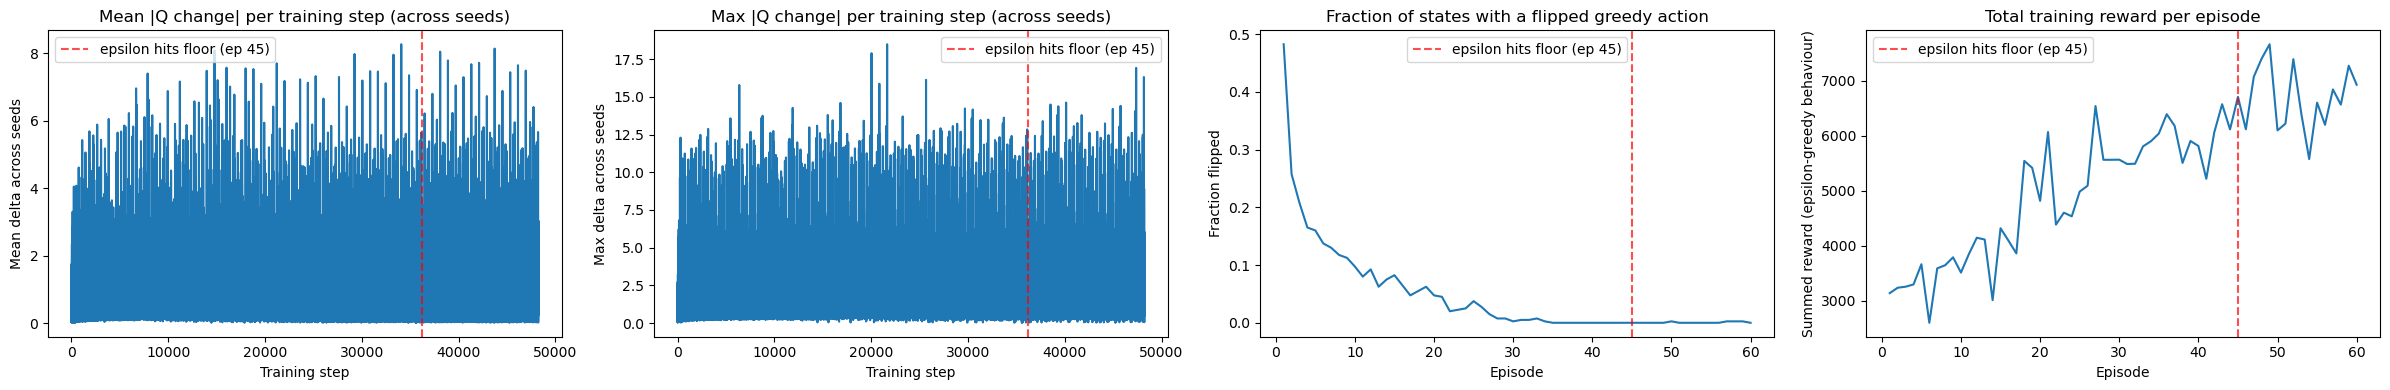

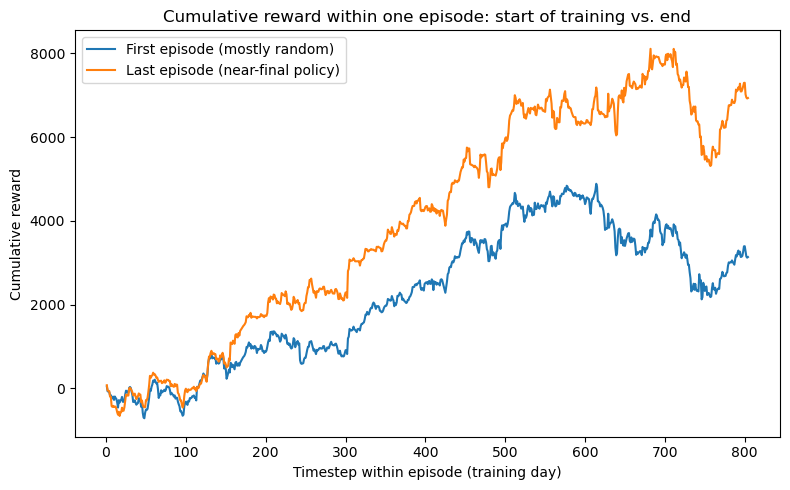

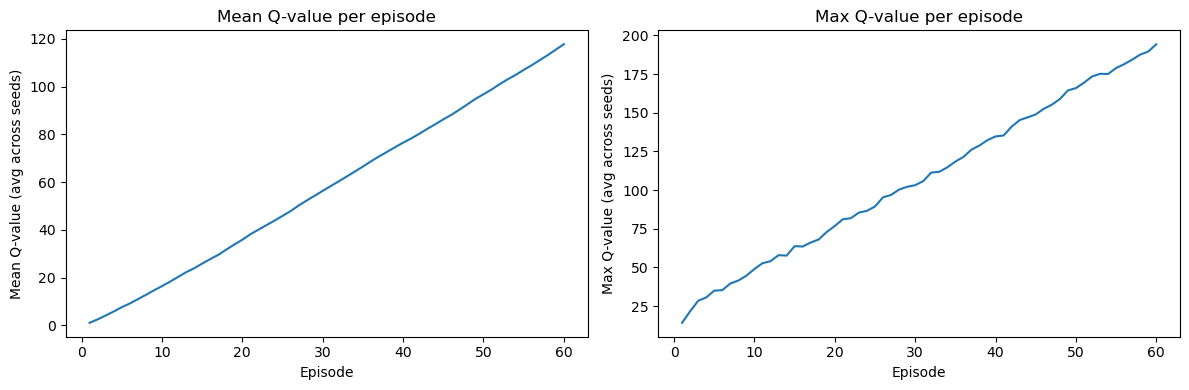

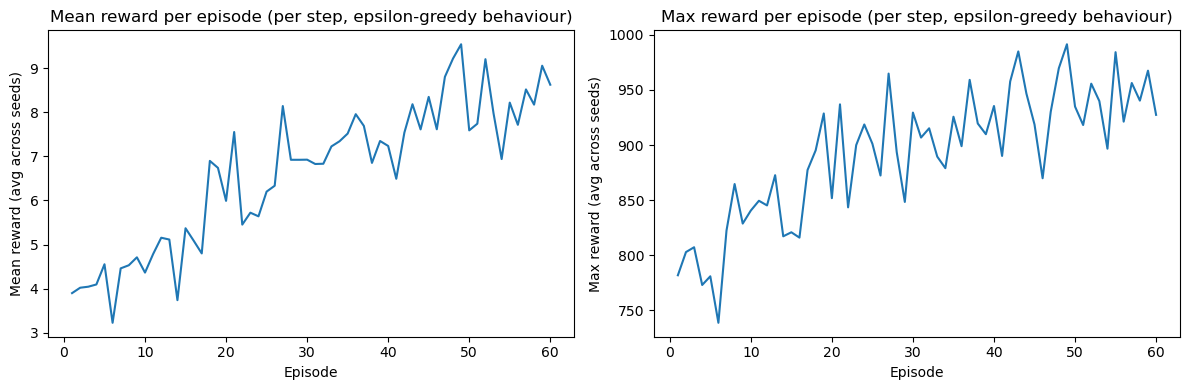


[Policy stability] States checked: 20/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 20 states -- mean: 80.7%  min: 50.0%  max: 100.0%

[State/action summary] 20/20 total states had >= 100 average visits across seeds
 state  avg_visits  majority_action  agreement_pct  mean_Q_majority_action
(0, 1)      2976.6                1           85.0                135.5738
(9, 0)      2780.9                0           60.0                124.9377
(8, 1)      2637.4                1          100.0                148.3007
(9, 1)      2619.0                0          100.0                172.3515
(1, 1)      2581.6                0           85.0                164.4419
(3, 1)      2503.7                1          100.0                148.4162
(8, 0)      2462.6                0           55.0                116.4185
(1, 0)      2458.4                1           70.0                147.7452
(2, 0)      2436.6

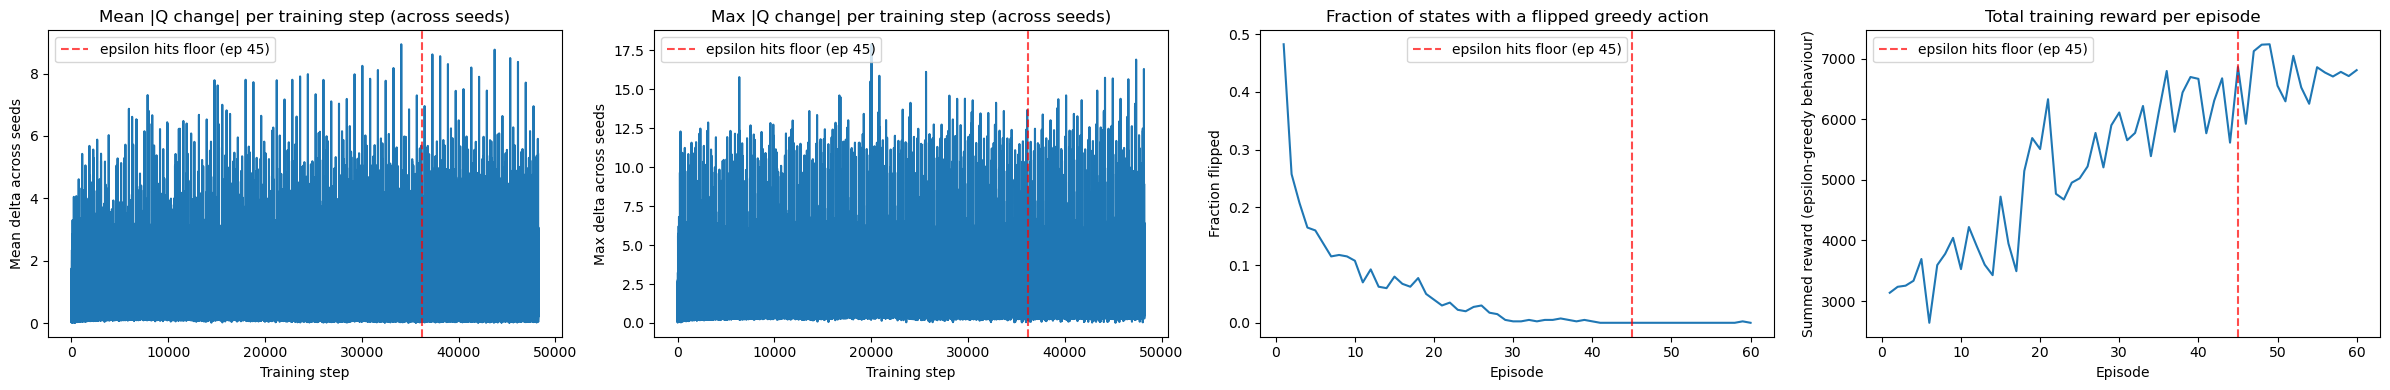

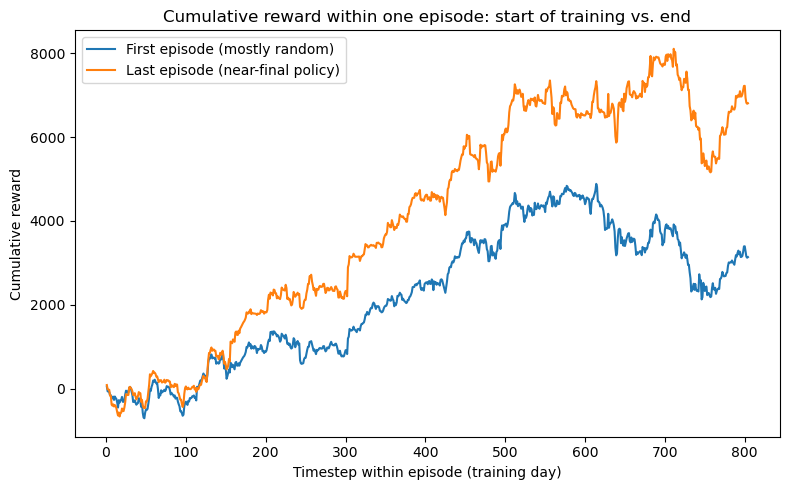

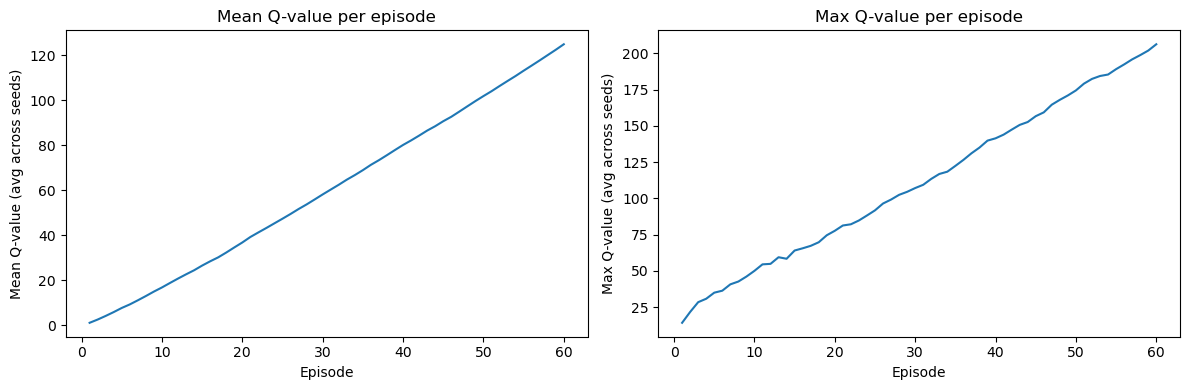

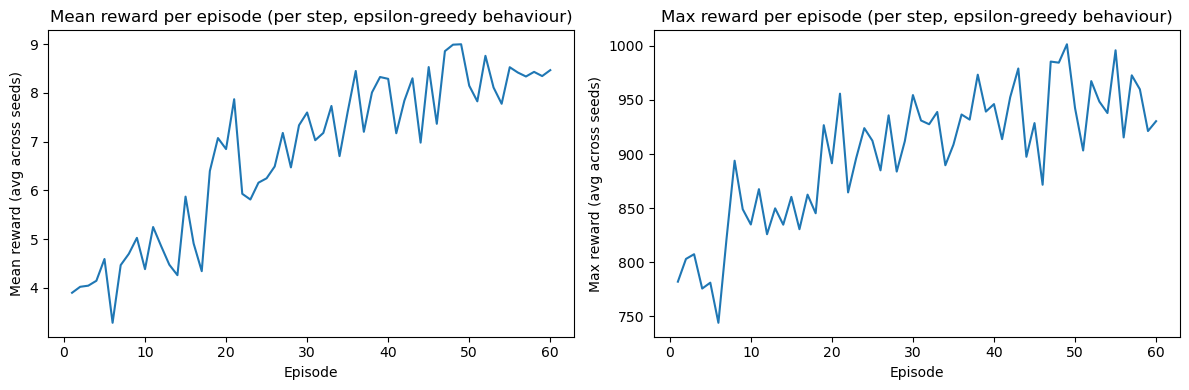


[Policy stability] States checked: 20/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 20 states -- mean: 80.8%  min: 50.0%  max: 100.0%

[State/action summary] 20/20 total states had >= 100 average visits across seeds
 state  avg_visits  majority_action  agreement_pct  mean_Q_majority_action
(0, 1)      2883.0                1           80.0                136.8682
(9, 0)      2879.6                0           50.0                125.7640
(8, 1)      2568.8                1           90.0                150.7759
(1, 0)      2553.6                1           75.0                159.2417
(8, 0)      2531.2                0           55.0                123.3468
(3, 0)      2529.7                0          100.0                160.7847
(9, 1)      2520.4                0           95.0                178.5065
(2, 0)      2504.3                0           65.0                134.8179
(1, 1)      2486.4

,eta,gamma,train_mean,train_std,val_mean,val_std
0,0.010,0.990,11907.7165,377.324378,12232.6025,1333.975854
1,0.010,0.995,11904.9065,428.411574,12145.3725,1437.724753
2,0.010,0.950,12033.4175,437.728625,11968.0450,1140.077710
3,0.001,0.990,12164.5105,447.144212,11765.1445,1207.375711
4,0.001,0.995,12189.4575,463.803187,11720.4210,1134.591552
5,0.001,0.950,12279.3565,452.067417,11544.4800,998.855082


In [ ]:
N = 20
episodes = 60
eta = 0.01
gamma = 0.95
epsilon = 1.0
epsilon_decay = 0.95
epsilon_floor = 0.1
initial_cash = 10000

q_learning_search = grid_search_hyperparameters(train_and_evaluate_greedy, eta_grid, gamma_grid, N=20, episodes=episodes,
                                  epsilon_start=epsilon, epsilon_decay=epsilon_decay, epsilon_floor=epsilon_floor, run_diagnostics=True)
print("Q-learning -- best (eta, gamma):", tuple(q_learning_search.iloc[0][["eta", "gamma"]]))
q_learning_search

In [ ]:
def evaluate_best_hyperparameters(train_fn, eta_best, gamma_best, N=50, episodes=episodes,
                                    epsilon_start=epsilon, epsilon_decay=epsilon_decay, epsilon_floor=epsilon_floor):
    """Retrain N seeds on the FULL train_raw with the given (eta, gamma), evaluate on
    the true held-out test_raw, and return everything needed both for the comparison
    table and for running full diagnostics on this tuned run.
    episodes/epsilon_start/epsilon_decay/epsilon_floor default to the notebook's
    global values but can be overridden here without touching those globals."""
    train_vals = np.zeros(N)
    test_vals = np.zeros(N)
    seed_agents = []
    all_step_delta_history = []
    all_test_actions = []
    all_policy_flip_history = []
    all_episode_reward_history = []
    all_first_episode_reward_trace = []
    all_last_episode_reward_trace = []
    all_Q_value_mean_history = []
    all_Q_value_max_history = []
    all_Reward_mean_history = []
    all_Reward_max_history = []
    Q_mean_values = []
    all_first_episode_q_mean_trace = []
    all_first_episode_q_max_trace = []
    all_last_episode_q_mean_trace = []
    all_last_episode_q_max_trace = []

    for seed in range(N):
        (agent, train_final, test_final, step_delta_history, train_actions, test_actions,
         Q_mean, policy_flip_history, episode_reward_history, first_episode_reward_trace, last_episode_reward_trace,
         Q_value_mean_history, Q_value_max_history, Reward_mean_history, Reward_max_history,
         first_episode_q_mean_trace, first_episode_q_max_trace, last_episode_q_mean_trace, last_episode_q_max_trace) = train_fn(
            seed, train_raw, test_raw, episodes=episodes,
            n_bins=n_bins, n_actions=n_actions, eta=eta_best, gamma=gamma_best,
            epsilon_start=epsilon_start, epsilon_decay=epsilon_decay, epsilon_floor=epsilon_floor,
            bin_edges=bin_edges, n_cash_bins=n_cash_bins, cash_bin_edges=cash_bin_edges)
        train_vals[seed] = train_final
        test_vals[seed] = test_final
        seed_agents.append(agent)
        all_step_delta_history.append(step_delta_history)
        all_test_actions.append(test_actions)
        all_policy_flip_history.append(policy_flip_history)
        all_episode_reward_history.append(episode_reward_history)
        all_first_episode_reward_trace.append(first_episode_reward_trace)
        all_last_episode_reward_trace.append(last_episode_reward_trace)
        all_Q_value_mean_history.append(Q_value_mean_history)
        all_Q_value_max_history.append(Q_value_max_history)
        all_Reward_mean_history.append(Reward_mean_history)
        all_Reward_max_history.append(Reward_max_history)
        Q_mean_values.append(Q_mean)
        all_first_episode_q_mean_trace.append(first_episode_q_mean_trace)
        all_first_episode_q_max_trace.append(first_episode_q_max_trace)
        all_last_episode_q_mean_trace.append(last_episode_q_mean_trace)
        all_last_episode_q_max_trace.append(last_episode_q_max_trace)

    return {
        "train_results": train_vals,
        "test_results": test_vals,
        "seed_agents": seed_agents,
        "avg_delta_history_max": np.max(all_step_delta_history, axis=0),
        "avg_delta_history_mean": np.mean(all_step_delta_history, axis=0),
        "avg_visit_counts": np.mean([agent.visit_counts for agent in seed_agents], axis=0),
        "all_test_actions": all_test_actions,
        "avg_policy_flip_history": np.mean(all_policy_flip_history, axis=0),
        "avg_episode_reward_history": np.mean(all_episode_reward_history, axis=0),
        "avg_first_episode_reward_trace": np.mean(all_first_episode_reward_trace, axis=0),
        "avg_last_episode_reward_trace": np.mean(all_last_episode_reward_trace, axis=0),
        "avg_Q_value_mean_history": np.mean(all_Q_value_mean_history, axis=0),
        "avg_Q_value_max_history": np.mean(all_Q_value_max_history, axis=0),
        "avg_Reward_mean_history": np.mean(all_Reward_mean_history, axis=0),
        "avg_Reward_max_history": np.mean(all_Reward_max_history, axis=0),
        "avg_Q_mean": np.mean(Q_mean_values, axis=0),
        "avg_first_episode_q_mean_trace": np.mean(all_first_episode_q_mean_trace, axis=0),
        "avg_first_episode_q_max_trace": np.mean(all_first_episode_q_max_trace, axis=0),
        "avg_last_episode_q_mean_trace": np.mean(all_last_episode_q_mean_trace, axis=0),
        "avg_last_episode_q_max_trace": np.mean(all_last_episode_q_max_trace, axis=0),
        # the actual epsilon schedule this run used -- stashed here (same reasoning as in
        # "Standard Reinforcement Learning.ipynb") so the tuned-diagnostics call below draws its
        # epsilon-floor line using the value ACTUALLY used here (epsilon_floor defaults to 0.0 in
        # this function, not the notebook's global epsilon_floor, unless explicitly overridden)
        "epsilon_start": epsilon_start,
        "epsilon_decay": epsilon_decay,
        "epsilon_floor": epsilon_floor,
    }

Generally the best eta_q and gamma_q are based on the validation values. The best values also need to have a high mean agreement rate with actions and have policy stability.

### Q changes graph

In the graphs, note that the Q value doesn't actually converge which is not ideal. However, the actions don't flip after 50 episodes suggesting that the values are unlikely to change. 

Furthermore, the increasing mean/max values of Q suggest that the overall effect of Q change decreases, despite its magnitude remaining constant through episodes.

### Solutions Tried

High Q value initialization doesn't provide a satisfactory solution here, the Q convergence issue doesn't change and the models actually give worse solutions.

Reward scaling i.e fixing the reward to a smaller amount doesn't work either

In [ ]:
N = 50
episodes = 100
eta = 0.01
gamma = 0.99
epsilon = 1.0
epsilon_decay = 0.95
# change epsilon floor to 0 for final run for fully converged model
epsilon_floor = 0
initial_cash = 10000

best_eta_q, best_gamma_q = q_learning_search.iloc[0][["eta", "gamma"]]
best_q = evaluate_best_hyperparameters(train_and_evaluate_greedy, best_eta_q, best_gamma_q)

run_full_diagnostics(
    visit_counts=best_q["avg_visit_counts"],
    delta_history=best_q["avg_delta_history_max"],
    delta_history_mean=best_q["avg_delta_history_mean"],
    seed_agents=best_q["seed_agents"],
    greedy_actions=best_q["all_test_actions"],
    n_actions=n_actions,
    epsilon_start = best_q["epsilon_start"],
    epsilon_decay = best_q["epsilon_decay"],
    epsilon_floor = best_q["epsilon_floor"],
    train_results = best_q["train_results"],
    test_results = best_q["test_results"],
    policy_flip_history=best_q["avg_policy_flip_history"],
    episode_reward_history=best_q["avg_episode_reward_history"],
    first_episode_reward_trace=best_q["avg_first_episode_reward_trace"],
    last_episode_reward_trace=best_q["avg_last_episode_reward_trace"],
    q_mean_history=best_q["avg_Q_value_mean_history"],
    q_max_history=best_q["avg_Q_value_max_history"],
    reward_mean_history=best_q["avg_Reward_mean_history"],
    reward_max_history=best_q["avg_Reward_max_history"],
)

In [23]:
best_eta_q, best_gamma_q = q_learning_search.iloc[0][["eta", "gamma"]]
best_q = evaluate_best_hyperparameters(train_and_evaluate_greedy, best_eta_q, best_gamma_q)


DIAGNOSTIC CHECKLIST
[Train/Test] Train -- mean: 12124.46  std: 315.32
[Train/Test] Test  -- mean: 11767.77  std: 631.99

[Coverage] Unvisited (state, action) pairs: 0 / 40 (0.0%)



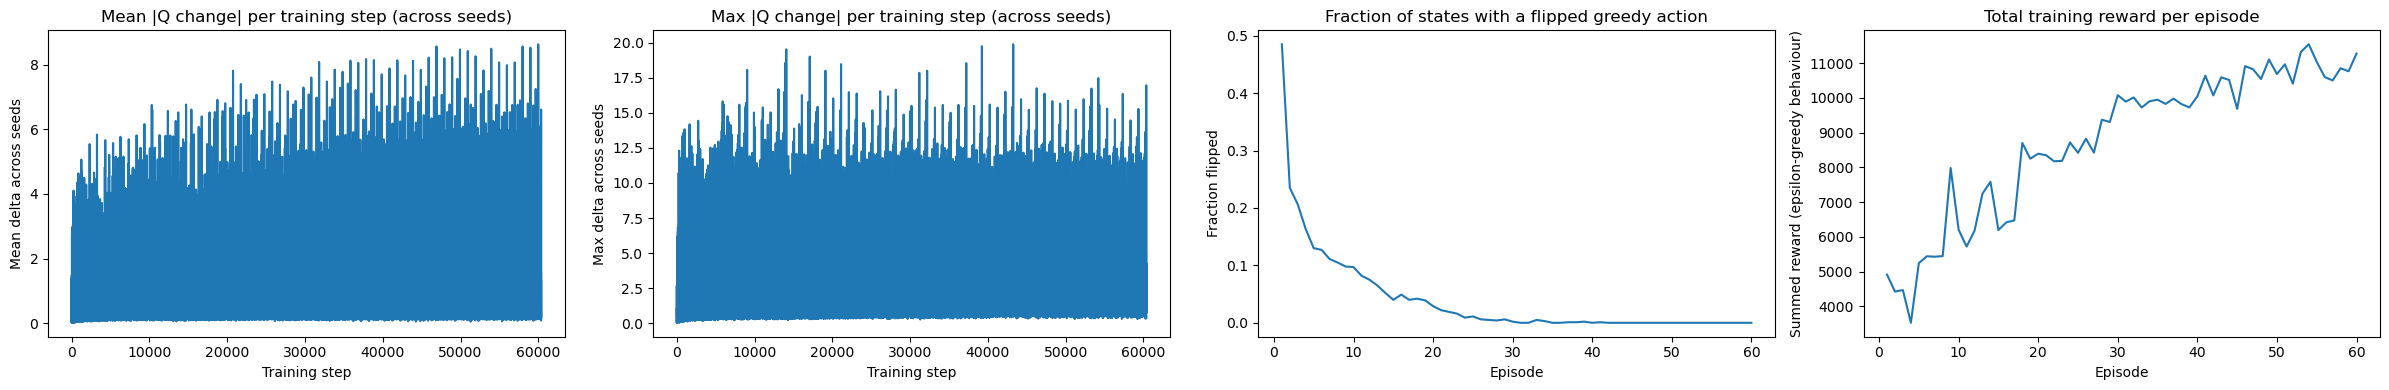

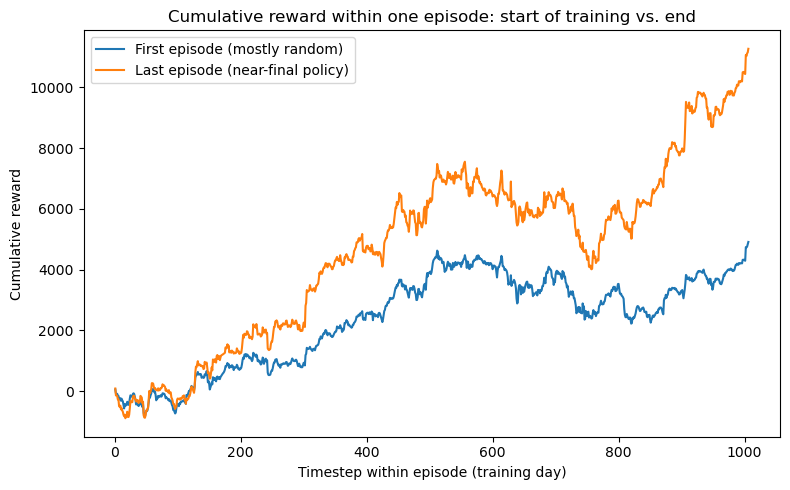

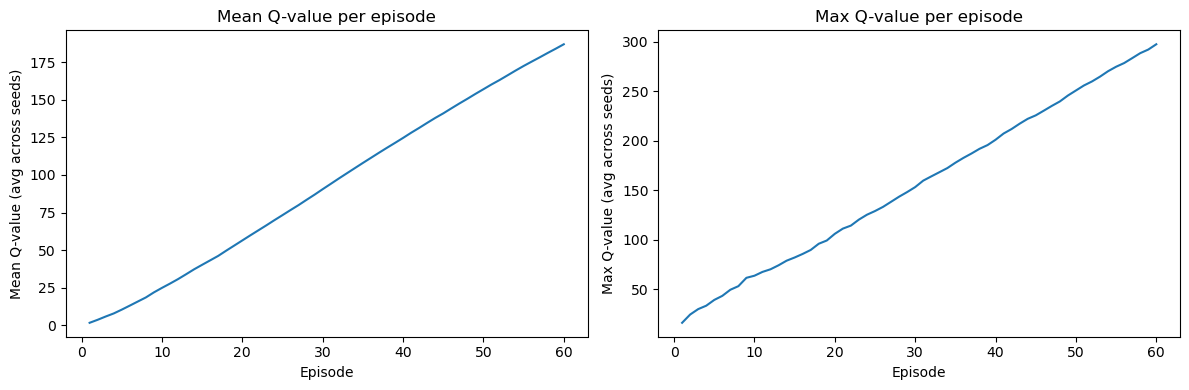

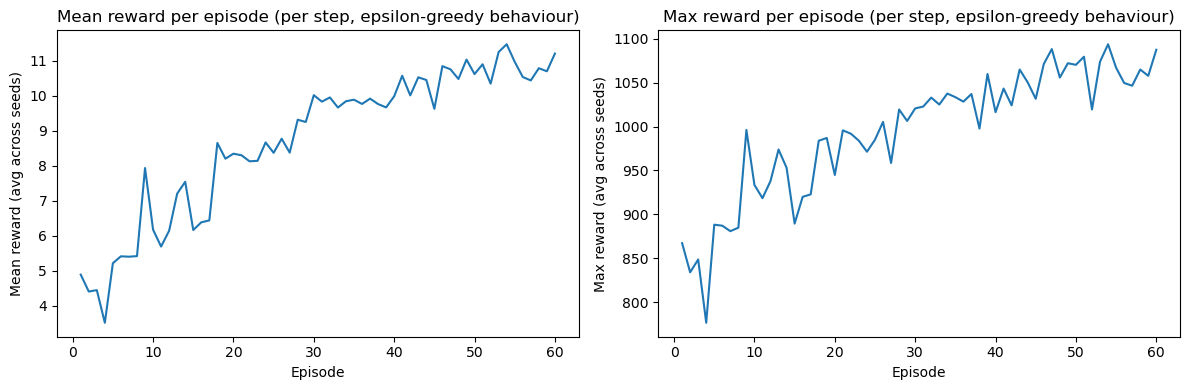


[Policy stability] States checked: 20/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 20 states -- mean: 82.1%  min: 52.0%  max: 100.0%

[State/action summary] 20/20 total states had >= 100 average visits across seeds
 state  avg_visits  majority_action  agreement_pct  mean_Q_majority_action
(4, 0)      3785.8                1          100.0                287.4625
(2, 0)      3653.4                0           64.0                200.4447
(8, 0)      3631.4                1           90.0                259.7130
(9, 0)      3615.6                1           96.0                255.5875
(7, 0)      3576.6                1           90.0                261.9266
(3, 0)      3560.6                0           74.0                206.6332
(6, 0)      3549.4                0           88.0                220.6751
(1, 0)      3472.6                1           66.0                218.7617
(5, 0)      3465.5

In [24]:
run_full_diagnostics(
    visit_counts=best_q["avg_visit_counts"],
    delta_history=best_q["avg_delta_history_max"],
    delta_history_mean=best_q["avg_delta_history_mean"],
    seed_agents=best_q["seed_agents"],
    greedy_actions=best_q["all_test_actions"],
    n_actions=n_actions,
    epsilon_start = best_q["epsilon_start"],
    epsilon_decay = best_q["epsilon_decay"],
    epsilon_floor = best_q["epsilon_floor"],
    train_results = best_q["train_results"],
    test_results = best_q["test_results"],
    policy_flip_history=best_q["avg_policy_flip_history"],
    episode_reward_history=best_q["avg_episode_reward_history"],
    first_episode_reward_trace=best_q["avg_first_episode_reward_trace"],
    last_episode_reward_trace=best_q["avg_last_episode_reward_trace"],
    q_mean_history=best_q["avg_Q_value_mean_history"],
    q_max_history=best_q["avg_Q_value_max_history"],
    reward_mean_history=best_q["avg_Reward_mean_history"],
    reward_max_history=best_q["avg_Reward_max_history"],
)

## Comparison Table for Apple Stock

In [64]:
import pandas as pd

def fmt(values):
    values = np.asarray(values)
    return f"{values.mean():.2f} ± {values.std():.2f}"

comparison_rows = {
    "Reinforcement Learning": (best_q["train_results"], best_q["test_results"]),
    "Random Trading": (random_train_results, random_test_results),
    "Buy and Hold": (np.array([buy_hold_train]), np.array([buy_hold_test])),
}

final_comparison_df = pd.DataFrame({
    "Train": [fmt(train_vals) for train_vals, test_vals in comparison_rows.values()],
    "Test": [fmt(test_vals) for train_vals, test_vals in comparison_rows.values()],
}, index=list(comparison_rows.keys()))

final_comparison_df

,Train,Test
Reinforcement Learning,11904.08 ± 218.68,12290.34 ± 443.99
Random Trading,10463.92 ± 513.91,11345.57 ± 914.14
Buy and Hold,10640.31 ± 0.00,13110.34 ± 0.00


The reinforcement learning model is consistently better than the random trading model throughout. 

It is better than the buy and hold strategy during the training phase but not in the testing phase suggesting the model doesn't actually generalize well to different stocks.

### Alternative Reinforcmement

Expected SARSA model and the double Q learning Model

### Expected SARSA Learning

For the extended SARSA the agent state needs to be slightly updated

In [36]:
class Agent_basic:
    def __init__(self, n_bins, n_cash_bins, n_actions=2, eta=0.1, gamma=0.95):
        self.Q = np.zeros((n_bins, n_cash_bins, n_actions))   # indexed by (return_bin, cash_bin, action)
        self.visit_counts = np.zeros((n_bins, n_cash_bins, n_actions), dtype=int)  # for the coverage diagnostic
        self.eta = eta       # step size, alpha
        self.gamma = gamma

    def select_action(self, s):
        return np.argmax(self.Q[s])   # s is a (return_bin, cash_bin) tuple

    def update(self, s, s_next, a, r):
        # standard Q-learning: bootstraps off the MAX over next-state actions (off-policy)
        target = r + self.gamma * np.max(self.Q[s_next])
        self.Q[s][a] = self.Q[s][a] + self.eta * (target - self.Q[s][a])
        self.visit_counts[s][a] += 1

    def update_expected_sarsa(self, s, s_next, a, r, epsilon):
        # Expected SARSA: bootstraps off the EXPECTED value of the next state under the
        # epsilon-greedy behaviour policy, instead of the max - same update rule shape as
        # Q-learning, just a different (lower-variance, on-policy) target
        q_next = self.Q[s_next]
        n_actions = len(q_next)
        greedy_action = np.argmax(q_next)
        action_probs = np.full(n_actions, epsilon / n_actions)
        action_probs[greedy_action] += (1 - epsilon)
        expected_q_next = np.sum(action_probs * q_next)
        target = r + self.gamma * expected_q_next
        self.Q[s][a] = self.Q[s][a] + self.eta * (target - self.Q[s][a])
        self.visit_counts[s][a] += 1

For expected SARSA, the same structure general run, hyperparameters, followed by the final run is used.

In [37]:
N = 50
episodes = 100
eta = 0.01
gamma = 0.95
epsilon = 1.0
epsilon_decay = 0.95
epsilon_floor = 0.1
initial_cash = 10000

In [38]:
def train_and_evaluate_expected_sarsa(seed, train_raw, test_raw, episodes=10, n_actions=2, eta=0.01, gamma=0.95,
                        epsilon_start=1.0, epsilon_decay=0.995, epsilon_floor=0.0, bin_edges=bin_edges,
                        cash_bin_edges=cash_bin_edges, n_bins=n_bins, n_cash_bins=n_cash_bins):
    np.random.seed(seed)

    agent = Agent_basic(n_bins=n_bins, n_cash_bins=n_cash_bins, n_actions=n_actions, eta=eta, gamma=gamma)
    train_size = len(train_raw)
    epsilon = epsilon_start
    step_delta_history = []
    policy_flip_history = []  # fraction of states whose greedy action (argmax Q) changed since the previous episode
    episode_reward_history = []  # total (epsilon-greedy) reward earned during each whole training episode
    Q_mean = []
    Q_value_mean_history = []
    Q_value_max_history = []
    Reward_mean_history = []
    Reward_max_history = []
    first_episode_reward_trace = None
    last_episode_reward_trace = None
    first_episode_q_mean_trace = None
    first_episode_q_max_trace = None
    last_episode_q_mean_trace = None
    last_episode_q_max_trace = None

    for ep in range(episodes):
        Q_before = agent.Q.copy()
        state = State_basic(train_raw, uninvested_cash=initial_cash, n_bins=n_bins, bin_edges=bin_edges,
                             n_cash_bins=n_cash_bins, cash_bin_edges=cash_bin_edges)
        track_trace = (ep == 0) or (ep == episodes - 1)
        reward_trace = [] if track_trace else None
        q_mean_trace = [] if track_trace else None
        q_max_trace = [] if track_trace else None
        episode_reward_total = 0.0
        episode_reward_max = -np.inf
        for t in range(train_size - 1):
            s = state.get_observation(t)
            if np.random.rand() < epsilon:
                a = np.random.randint(agent.Q.shape[-1])
            else:
                a = agent.select_action(s)
            r = state.reward(a, t)
            episode_reward_total += r
            episode_reward_max = max(episode_reward_max, r)
            if track_trace:
                reward_trace.append(r)
            s_next = state.get_observation(t + 1)
            q_before_step = agent.Q[s][a]
            # Expected SARSA update instead of Q-learning's max-based update -- see
            # Agent_basic.update_expected_sarsa for the bootstrapping target itself
            agent.update_expected_sarsa(s, s_next, a, r, epsilon)
            step_delta_history.append(abs(agent.Q[s][a] - q_before_step))
            if track_trace:
                q_mean_trace.append(agent.Q.mean())
                q_max_trace.append(agent.Q.max())
        epsilon = max(epsilon * epsilon_decay, epsilon_floor)
        policy_before = np.argmax(Q_before, axis=-1)
        policy_after = np.argmax(agent.Q, axis=-1)
        policy_flip_history.append(np.mean(policy_before != policy_after))
        Q_mean.append(agent.Q.mean(axis=1).mean(axis=0))
        Q_value_mean_history.append(agent.Q.mean())
        Q_value_max_history.append(agent.Q.max())
        episode_reward_history.append(episode_reward_total)
        Reward_mean_history.append(episode_reward_total / (train_size - 1))
        Reward_max_history.append(episode_reward_max)
        if ep == 0:
            first_episode_reward_trace = reward_trace
            first_episode_q_mean_trace = q_mean_trace
            first_episode_q_max_trace = q_max_trace
        if ep == episodes - 1:
            last_episode_reward_trace = reward_trace
            last_episode_q_mean_trace = q_mean_trace
            last_episode_q_max_trace = q_max_trace

    train_final, train_actions = run_greedy(train_raw, agent, n_bins=n_bins, n_cash_bins=n_cash_bins)
    test_final, test_actions = run_greedy(test_raw, agent, n_bins=n_bins, n_cash_bins=n_cash_bins)

    return (agent, train_final, test_final, step_delta_history, train_actions, test_actions,
            Q_mean, policy_flip_history, episode_reward_history, first_episode_reward_trace, last_episode_reward_trace,
            Q_value_mean_history, Q_value_max_history, Reward_mean_history, Reward_max_history,
            first_episode_q_mean_trace, first_episode_q_max_trace, last_episode_q_mean_trace, last_episode_q_max_trace)

In [39]:
train_results_sarsa = np.zeros(N)
test_results_sarsa = np.zeros(N)
seed_agents_sarsa = []             # every seed's trained agent, for coverage / policy-stability diagnostics
all_step_delta_history_sarsa = []  # every seed's per-training-step delta curve -- mean/max ACROSS SEEDS computed below
all_test_actions_sarsa = []        # every seed's greedy test rollout, for the action-distribution diagnostic
all_policy_flip_history_sarsa = []  # every seed's per-episode action-flip fraction, averaged for the convergence diagnostic
all_episode_reward_history_sarsa = []      # every seed's per-episode total training reward, averaged for the reward curve
all_first_episode_reward_trace_sarsa = []  # every seed's episode-0 per-timestep reward trace, averaged for the within-episode plot
all_last_episode_reward_trace_sarsa = []   # every seed's final-episode per-timestep reward trace, averaged for the within-episode plot
all_Q_value_mean_history_sarsa = []  # every seed's per-episode mean-Q-value curve, averaged for the Q-value-magnitude plot
all_Q_value_max_history_sarsa = []   # every seed's per-episode max-Q-value curve, averaged for the Q-value-magnitude plot
all_Reward_mean_history_sarsa = []   # every seed's per-episode mean-reward-per-step curve, averaged for the reward-magnitude plot
all_Reward_max_history_sarsa = []    # every seed's per-episode max-reward curve, averaged for the reward-magnitude plot
all_first_episode_q_mean_trace_sarsa = []  # every seed's episode-0 per-timestep Q-mean trace, for the sanity-check plot
all_first_episode_q_max_trace_sarsa = []   # every seed's episode-0 per-timestep Q-max trace, for the sanity-check plot
all_last_episode_q_mean_trace_sarsa = []   # every seed's final-episode per-timestep Q-mean trace, for the sanity-check plot
all_last_episode_q_max_trace_sarsa = []    # every seed's final-episode per-timestep Q-max trace, for the sanity-check plot
Q_mean_values_sarsa = []
for seed in range(N):
    (agent, train_final, test_final, step_delta_history, train_actions, test_actions,
     Q_mean, policy_flip_history, episode_reward_history, first_episode_reward_trace, last_episode_reward_trace,
     Q_value_mean_history, Q_value_max_history, Reward_mean_history, Reward_max_history,
     first_episode_q_mean_trace, first_episode_q_max_trace, last_episode_q_mean_trace, last_episode_q_max_trace) = train_and_evaluate_expected_sarsa(
        seed, train_raw, test_raw, episodes=episodes, n_bins=n_bins, n_actions=n_actions, eta=eta, gamma=gamma,
        epsilon_start=epsilon, epsilon_decay=epsilon_decay, epsilon_floor = epsilon_floor, bin_edges=bin_edges,
        n_cash_bins=n_cash_bins, cash_bin_edges=cash_bin_edges)
    train_results_sarsa[seed] = train_final
    test_results_sarsa[seed] = test_final
    seed_agents_sarsa.append(agent)
    all_step_delta_history_sarsa.append(step_delta_history)
    all_test_actions_sarsa.append(test_actions)
    all_policy_flip_history_sarsa.append(policy_flip_history)
    all_episode_reward_history_sarsa.append(episode_reward_history)
    all_first_episode_reward_trace_sarsa.append(first_episode_reward_trace)
    all_last_episode_reward_trace_sarsa.append(last_episode_reward_trace)
    all_Q_value_mean_history_sarsa.append(Q_value_mean_history)
    all_Q_value_max_history_sarsa.append(Q_value_max_history)
    all_Reward_mean_history_sarsa.append(Reward_mean_history)
    all_Reward_max_history_sarsa.append(Reward_max_history)
    all_first_episode_q_mean_trace_sarsa.append(first_episode_q_mean_trace)
    all_first_episode_q_max_trace_sarsa.append(first_episode_q_max_trace)
    all_last_episode_q_mean_trace_sarsa.append(last_episode_q_mean_trace)
    all_last_episode_q_max_trace_sarsa.append(last_episode_q_max_trace)
    Q_mean_values_sarsa.append(Q_mean)

avg_delta_history_mean_sarsa = np.mean(all_step_delta_history_sarsa, axis=0)  # mean across seeds, per training step
avg_delta_history_max_sarsa = np.max(all_step_delta_history_sarsa, axis=0)    # max across seeds, per training step
avg_policy_flip_history_sarsa = np.mean(all_policy_flip_history_sarsa, axis=0)
avg_episode_reward_history_sarsa = np.mean(all_episode_reward_history_sarsa, axis=0)
avg_first_episode_reward_trace_sarsa = np.mean(all_first_episode_reward_trace_sarsa, axis=0)
avg_last_episode_reward_trace_sarsa = np.mean(all_last_episode_reward_trace_sarsa, axis=0)
avg_Q_value_mean_history_sarsa = np.mean(all_Q_value_mean_history_sarsa, axis=0)
avg_Q_value_max_history_sarsa = np.mean(all_Q_value_max_history_sarsa, axis=0)
avg_Reward_mean_history_sarsa = np.mean(all_Reward_mean_history_sarsa, axis=0)
avg_Reward_max_history_sarsa = np.mean(all_Reward_max_history_sarsa, axis=0)
avg_first_episode_q_mean_trace_sarsa = np.mean(all_first_episode_q_mean_trace_sarsa, axis=0)
avg_first_episode_q_max_trace_sarsa = np.mean(all_first_episode_q_max_trace_sarsa, axis=0)
avg_last_episode_q_mean_trace_sarsa = np.mean(all_last_episode_q_mean_trace_sarsa, axis=0)
avg_last_episode_q_max_trace_sarsa = np.mean(all_last_episode_q_max_trace_sarsa, axis=0)
avg_Q_mean_sarsa = np.mean(Q_mean_values_sarsa, axis=0)
avg_visit_counts_sarsa = np.mean([agent.visit_counts for agent in seed_agents_sarsa], axis=0)

print(f"Episodes = {episodes}")
print(f"Expected SARSA (greedy) -- Train: mean={train_results_sarsa.mean():.2f}, std={train_results_sarsa.std():.2f}")
print(f"Expected SARSA (greedy) -- Test:  mean={test_results_sarsa.mean():.2f}, std={test_results_sarsa.std():.2f}")

Episodes = 100
Expected SARSA (greedy) -- Train: mean=12121.46, std=252.46
Expected SARSA (greedy) -- Test:  mean=12228.73, std=715.16


DIAGNOSTIC CHECKLIST
[Train/Test] Train -- mean: 12121.46  std: 252.46
[Train/Test] Test  -- mean: 12228.73  std: 715.16

[Coverage] Unvisited (state, action) pairs: 0 / 40 (0.0%)



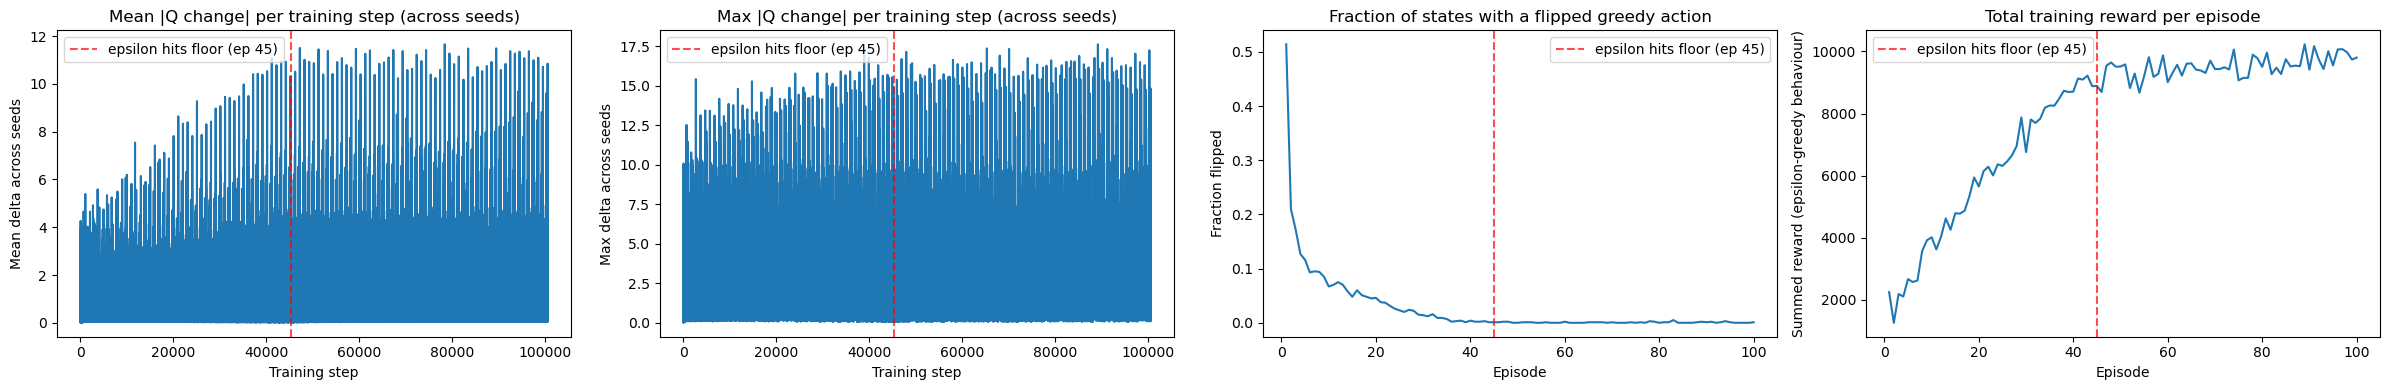

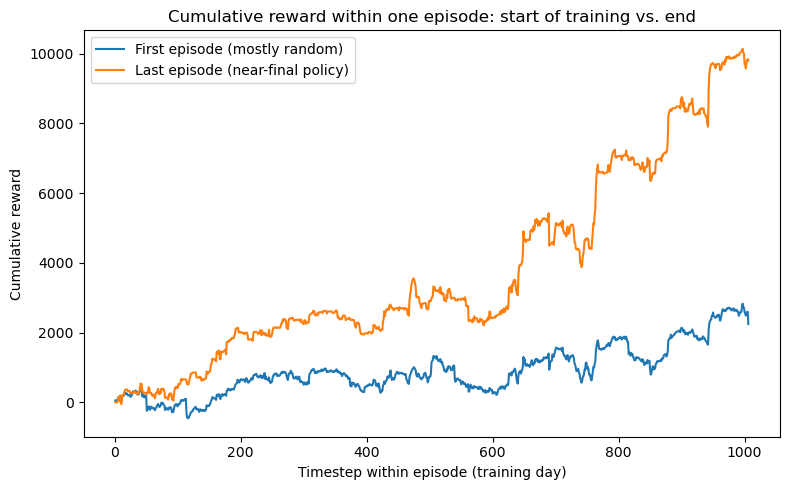

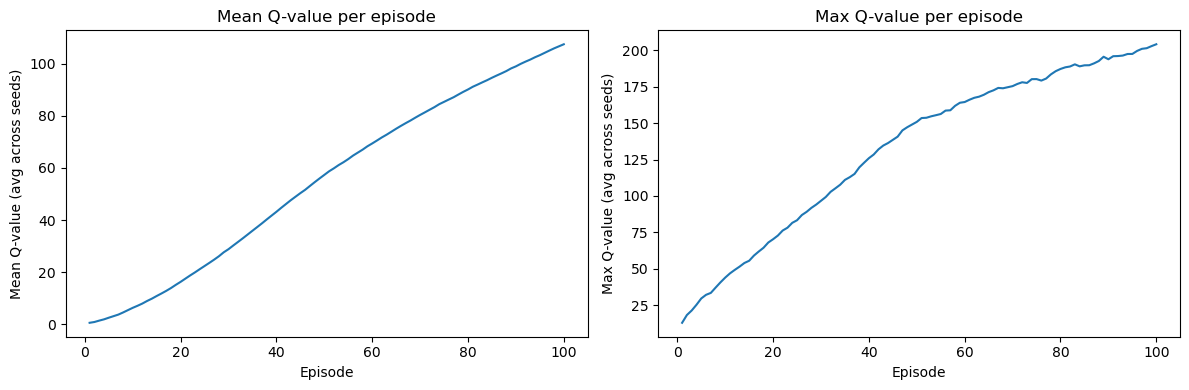

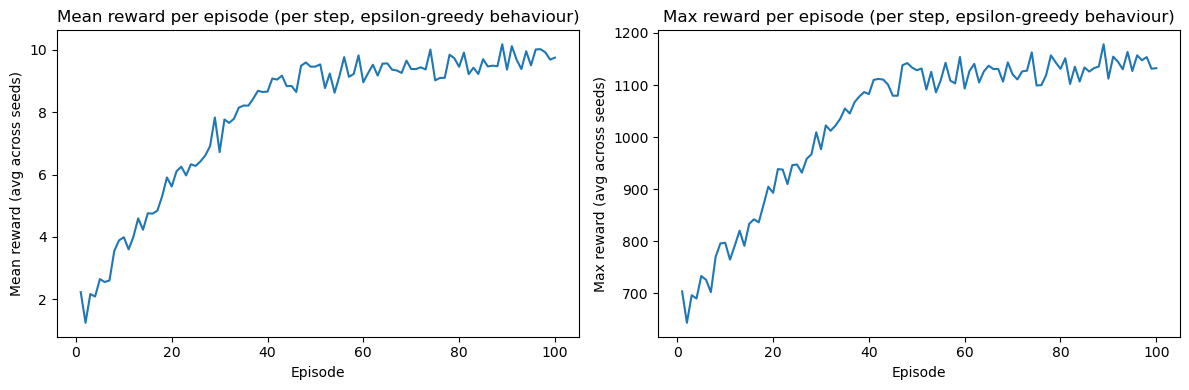


[Policy stability] States checked: 20/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 20 states -- mean: 93.0%  min: 68.0%  max: 100.0%

[State/action summary] 20/20 total states had >= 100 average visits across seeds
 state  avg_visits  majority_action  agreement_pct  mean_Q_majority_action
(0, 1)      5788.9                1           72.0                107.3090
(9, 0)      5591.4                1          100.0                204.0439
(1, 1)      5513.1                0           68.0                115.9627
(4, 1)      5481.9                1          100.0                119.2141
(6, 1)      5286.5                1           98.0                115.9353
(5, 1)      5238.5                1           96.0                114.6806
(8, 0)      5159.1                1           72.0                131.0994
(7, 1)      5152.0                0          100.0                156.4850
(2, 0)      5135.5

In [40]:
run_full_diagnostics(
    visit_counts=avg_visit_counts_sarsa,
    delta_history=avg_delta_history_max_sarsa,
    delta_history_mean=avg_delta_history_mean_sarsa,
    seed_agents=seed_agents_sarsa,
    greedy_actions=all_test_actions_sarsa,
    n_actions=n_actions,
    epsilon_start=epsilon,
    epsilon_decay=epsilon_decay,
    epsilon_floor=epsilon_floor,
    train_results=train_results_sarsa,
    test_results=test_results_sarsa,
    policy_flip_history=avg_policy_flip_history_sarsa,
    episode_reward_history=avg_episode_reward_history_sarsa,
    first_episode_reward_trace=avg_first_episode_reward_trace_sarsa,
    last_episode_reward_trace=avg_last_episode_reward_trace_sarsa,
    q_mean_history=avg_Q_value_mean_history_sarsa,
    q_max_history=avg_Q_value_max_history_sarsa,
    reward_mean_history=avg_Reward_mean_history_sarsa,
    reward_max_history=avg_Reward_max_history_sarsa,
)


--- eta=0.001, gamma=0.95 ---
DIAGNOSTIC CHECKLIST
[Train/Test] Train -- mean: 12824.98  std: 574.32
[Train/Test] Test  -- mean: 10496.10  std: 648.79

[Coverage] Unvisited (state, action) pairs: 0 / 40 (0.0%)



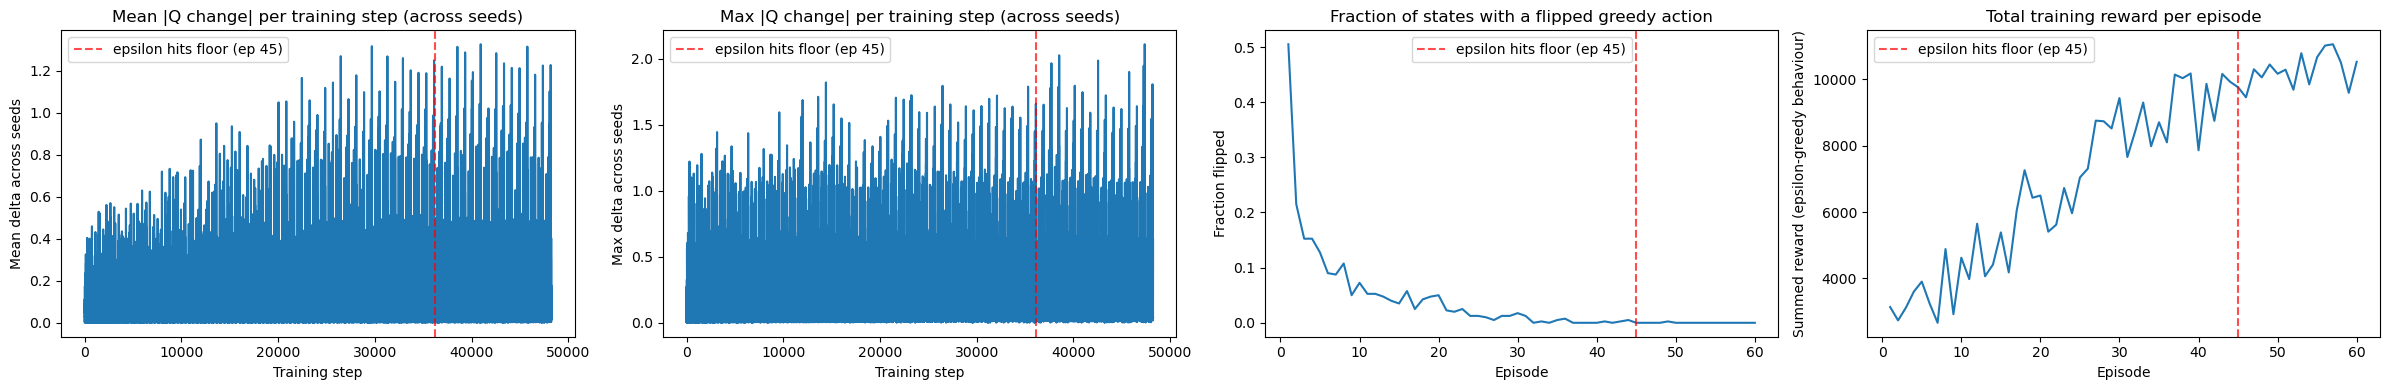

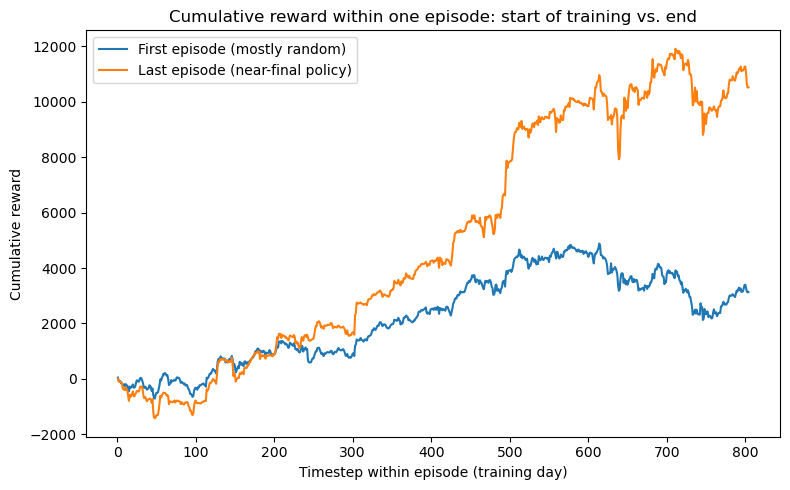

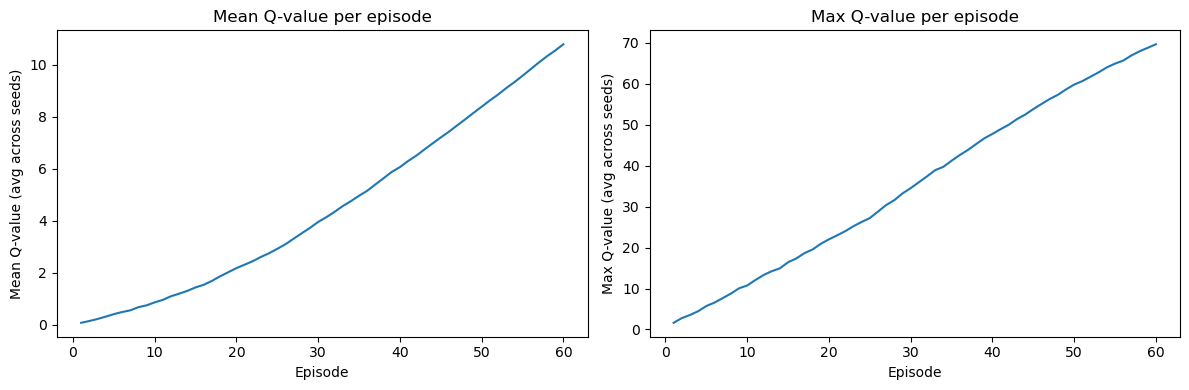

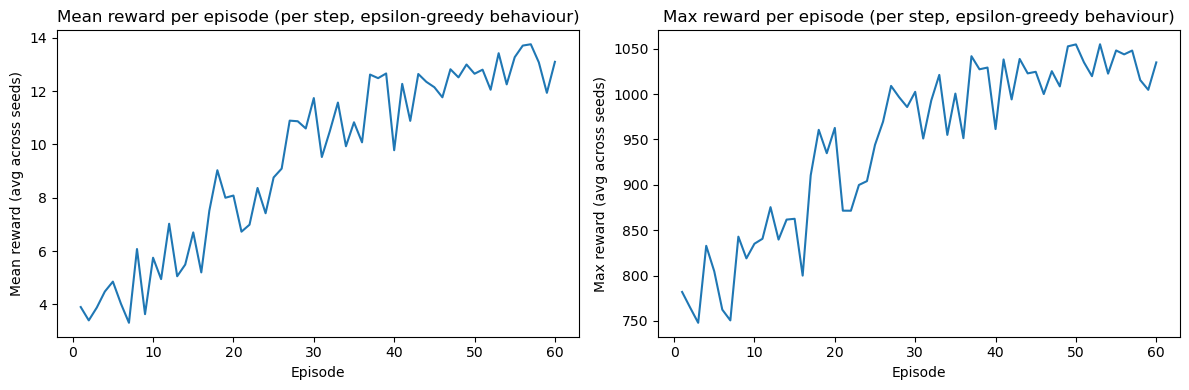


[Policy stability] States checked: 20/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 20 states -- mean: 86.5%  min: 60.0%  max: 100.0%

[State/action summary] 20/20 total states had >= 100 average visits across seeds
 state  avg_visits  majority_action  agreement_pct  mean_Q_majority_action
(9, 0)      5468.5                1           90.0                 35.7315
(9, 1)      3891.6                1           80.0                  8.5885
(0, 0)      3838.9                1           90.0                 32.0166
(0, 1)      3781.1                0           90.0                 28.7243
(8, 0)      2659.3                0           90.0                  7.8174
(1, 0)      2623.2                1           60.0                 17.3818
(2, 0)      2596.8                0           75.0                  8.1162
(1, 1)      2536.8                0           60.0                 11.3021
(2, 1)      2443.2

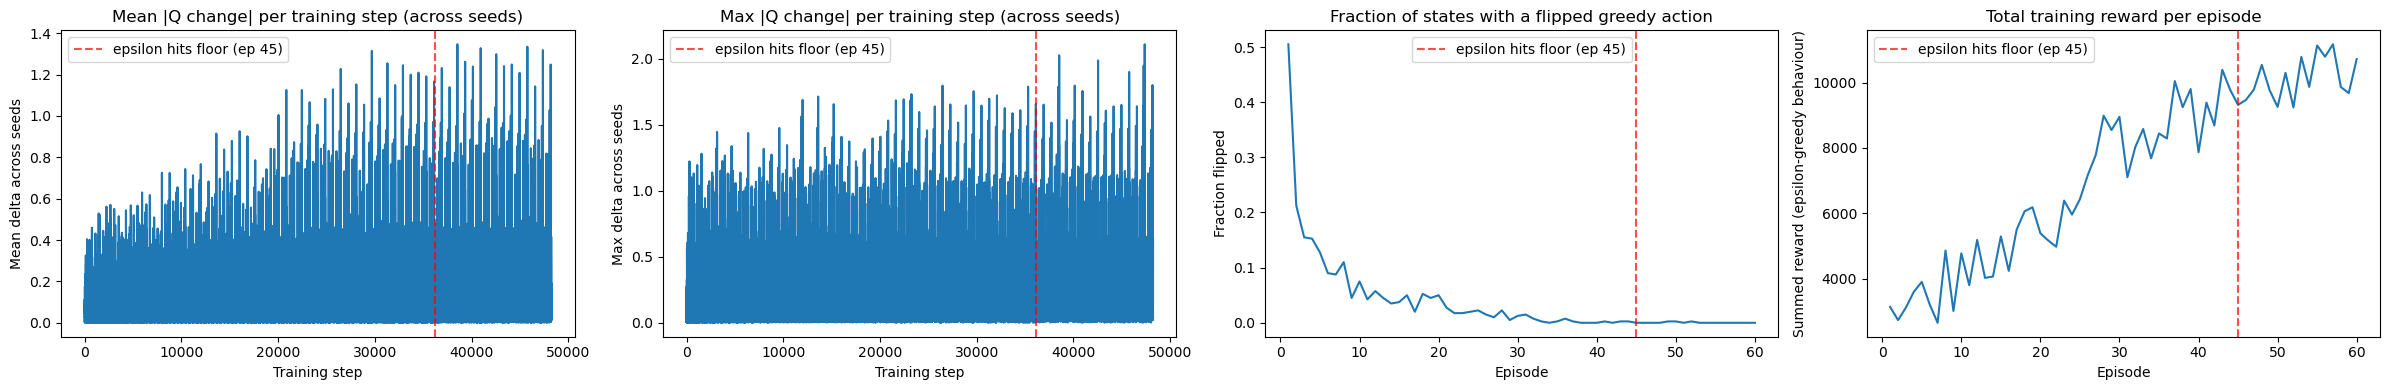

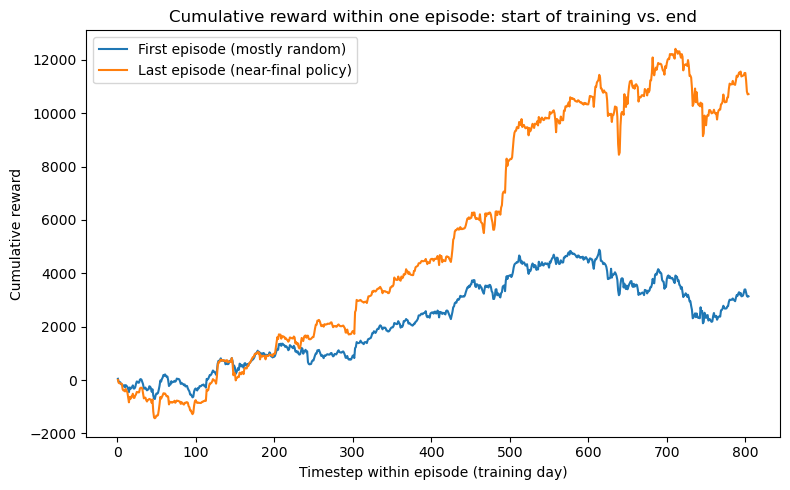

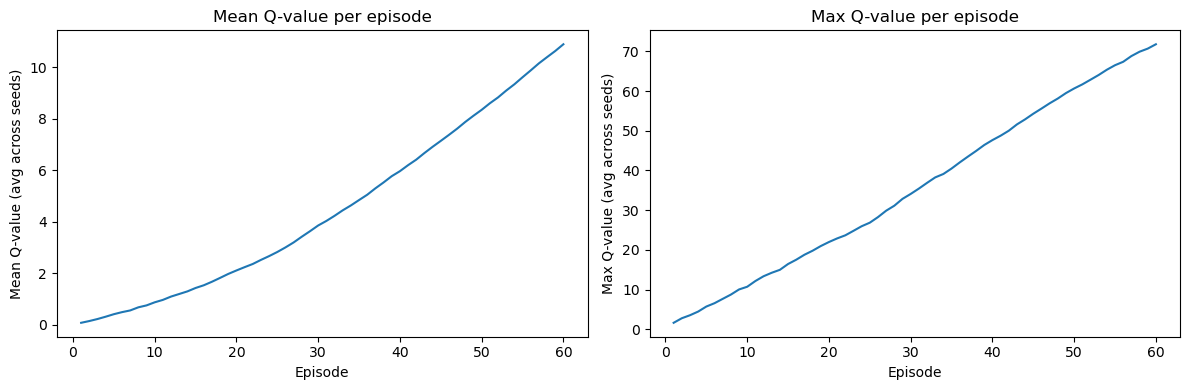

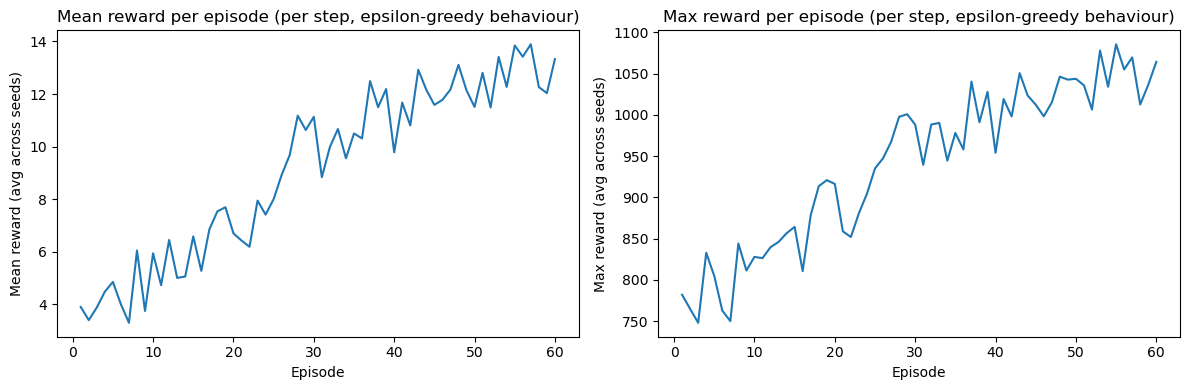


[Policy stability] States checked: 20/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 20 states -- mean: 86.2%  min: 55.0%  max: 100.0%

[State/action summary] 20/20 total states had >= 100 average visits across seeds
 state  avg_visits  majority_action  agreement_pct  mean_Q_majority_action
(9, 0)      5397.0                1           90.0                 37.4159
(9, 1)      3963.0                1           75.0                  8.5196
(0, 1)      3814.7                0           90.0                 28.9578
(0, 0)      3805.3                1           85.0                 32.3936
(8, 0)      2637.5                0           90.0                  8.0357
(1, 0)      2594.4                1           60.0                 17.1631
(2, 0)      2586.1                0           80.0                  8.7102
(1, 1)      2565.6                0           55.0                 11.3062
(8, 1)      2462.5

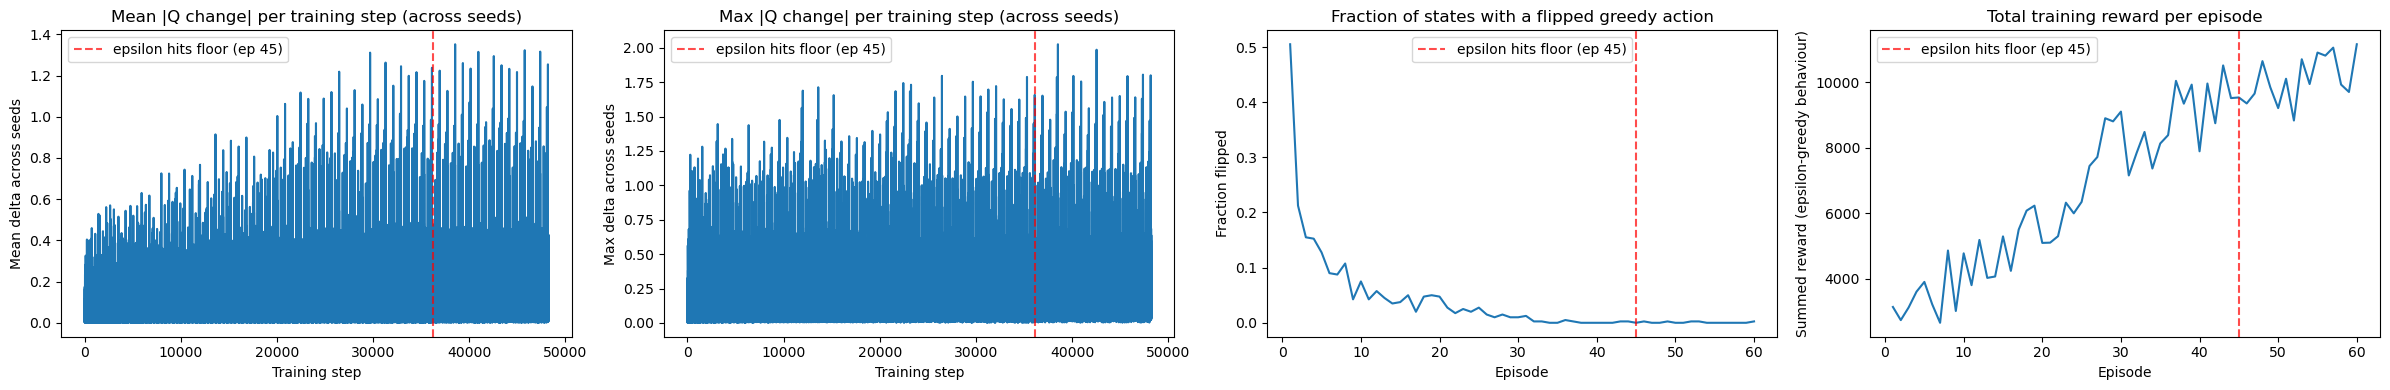

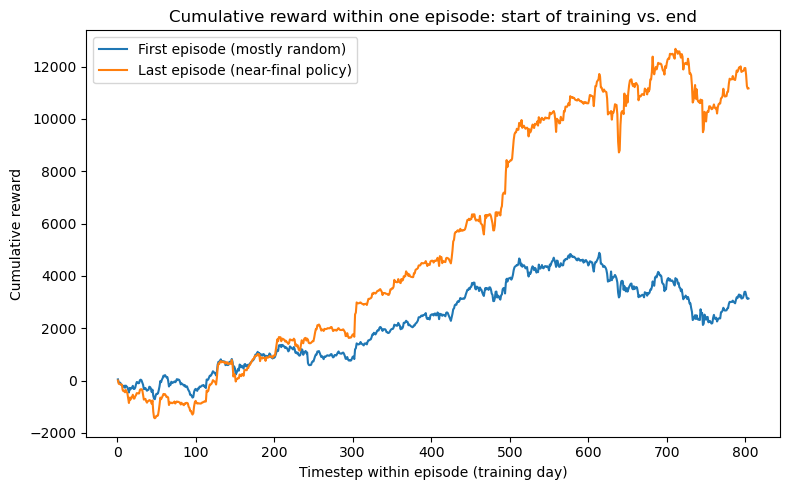

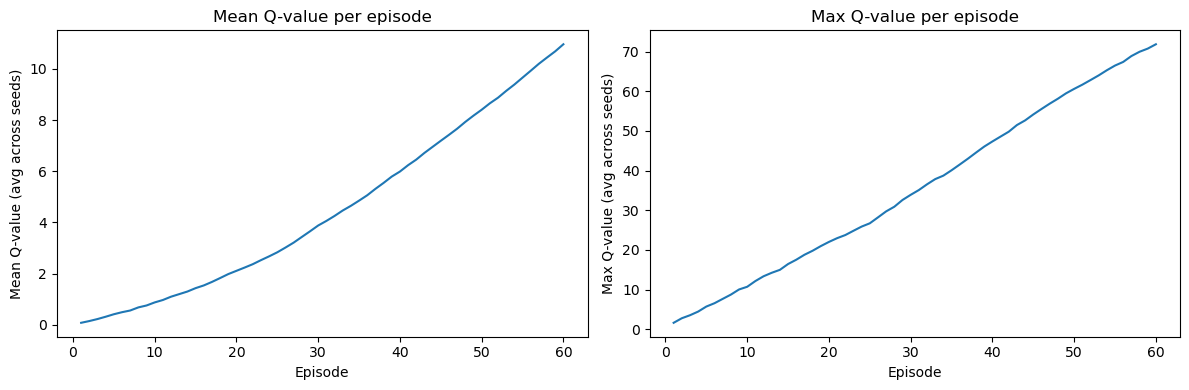

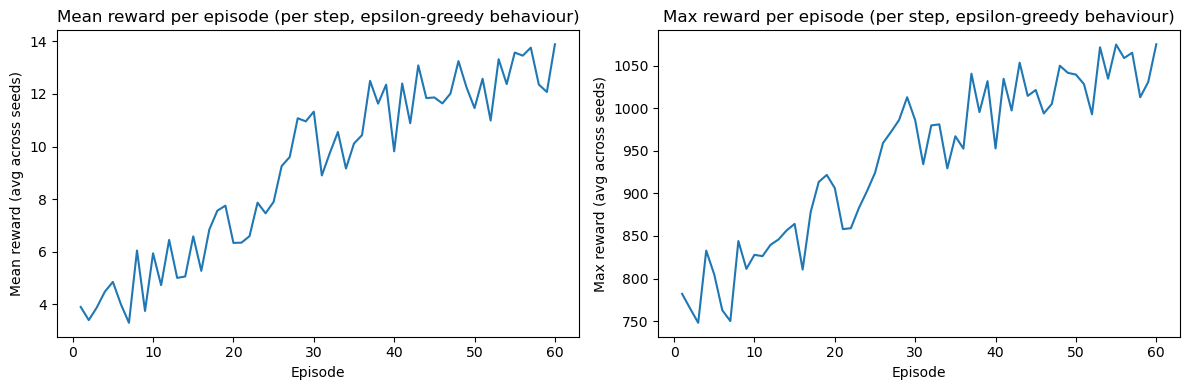


[Policy stability] States checked: 20/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 20 states -- mean: 85.2%  min: 50.0%  max: 100.0%

[State/action summary] 20/20 total states had >= 100 average visits across seeds
 state  avg_visits  majority_action  agreement_pct  mean_Q_majority_action
(9, 0)      5389.3                1           90.0                 37.7742
(9, 1)      3970.7                1           80.0                  8.7626
(0, 1)      3822.1                0           90.0                 29.4909
(0, 0)      3797.8                1           80.0                 32.1771
(8, 0)      2626.8                0           90.0                  8.1555
(1, 1)      2584.1                0           50.0                 10.7178
(1, 0)      2575.8                1           60.0                 17.3805
(2, 0)      2570.7                0           80.0                  8.7042
(8, 1)      2473.2

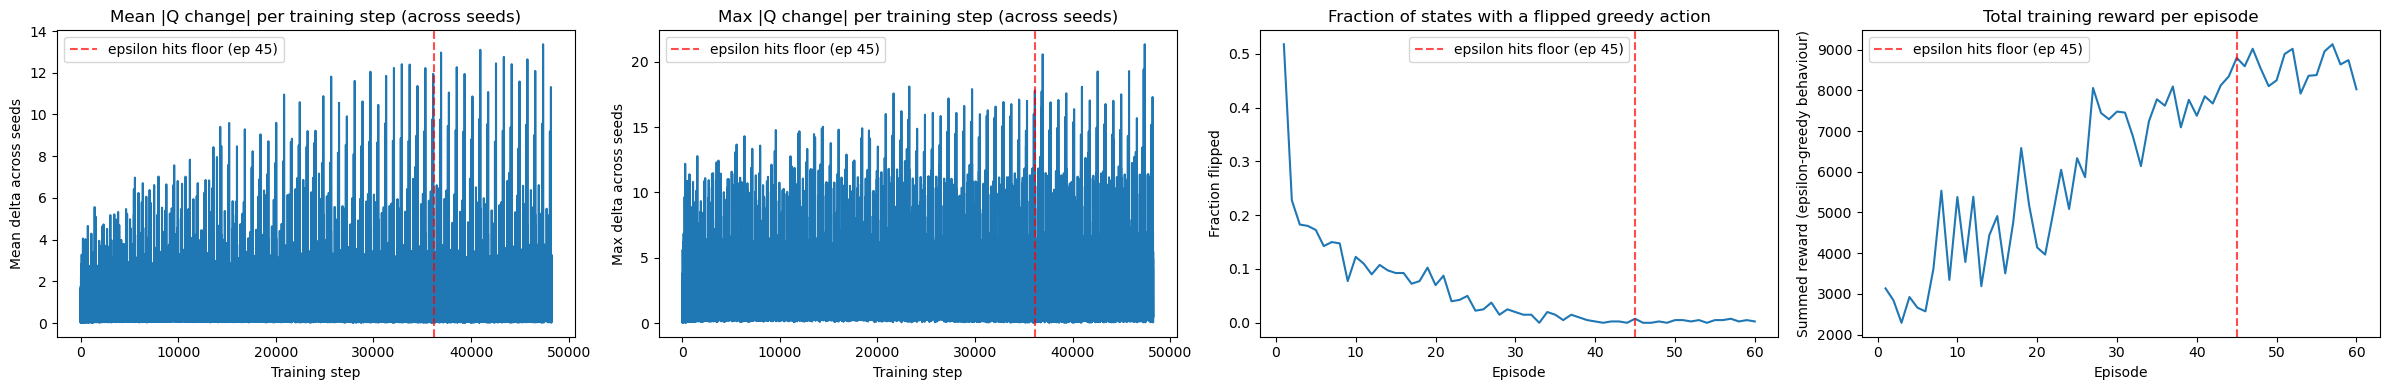

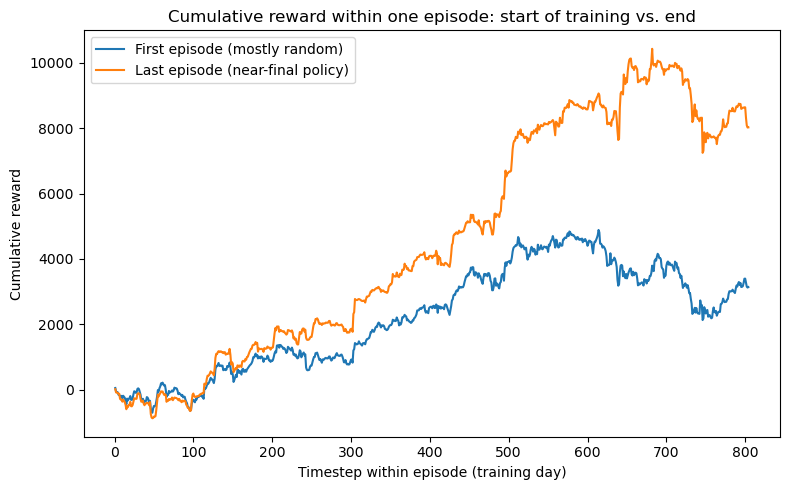

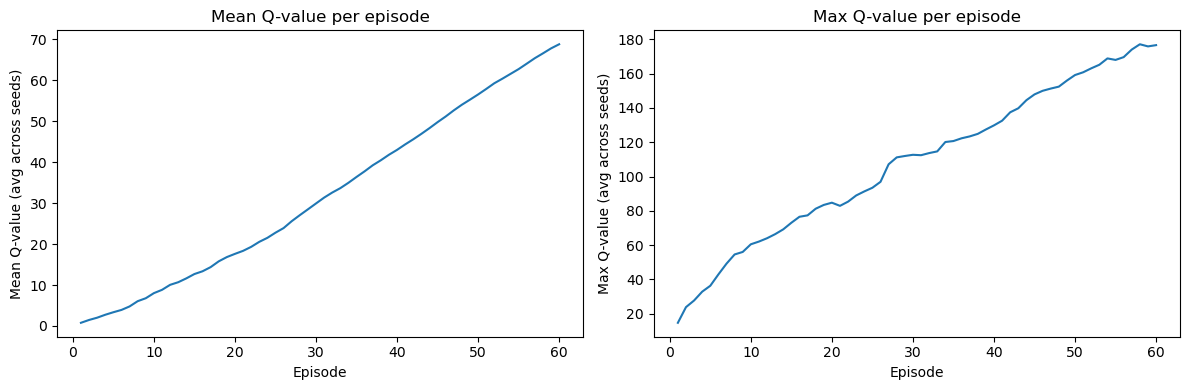

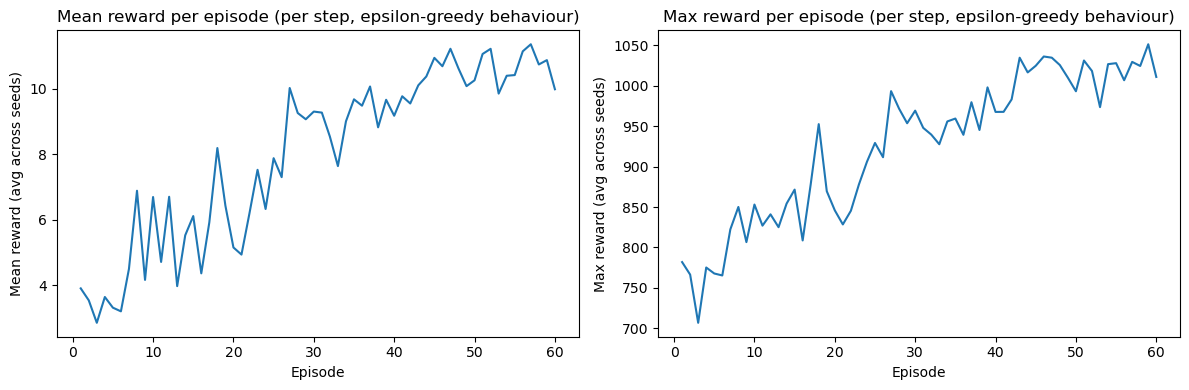


[Policy stability] States checked: 20/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 20 states -- mean: 85.5%  min: 50.0%  max: 100.0%

[State/action summary] 20/20 total states had >= 100 average visits across seeds
 state  avg_visits  majority_action  agreement_pct  mean_Q_majority_action
(9, 1)      4739.7                1          100.0                 86.3827
(9, 0)      4620.3                1           85.0                115.5378
(0, 1)      4450.3                0           60.0                 93.6126
(0, 0)      3169.7                0           50.0                 72.0139
(1, 1)      2964.2                1           80.0                 81.1899
(8, 1)      2942.5                1           55.0                 65.5289
(2, 1)      2876.2                1          100.0                 87.0320
(1, 0)      2195.8                0           50.0                 66.1664
(5, 1)      2178.9

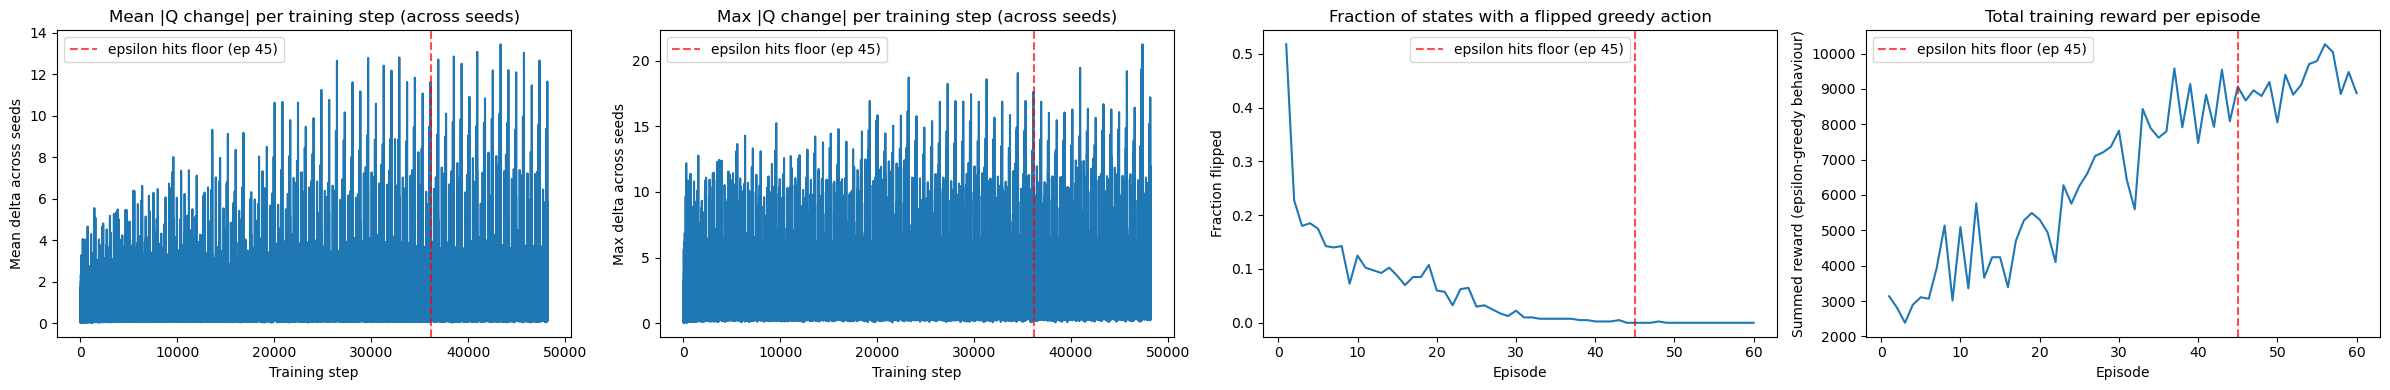

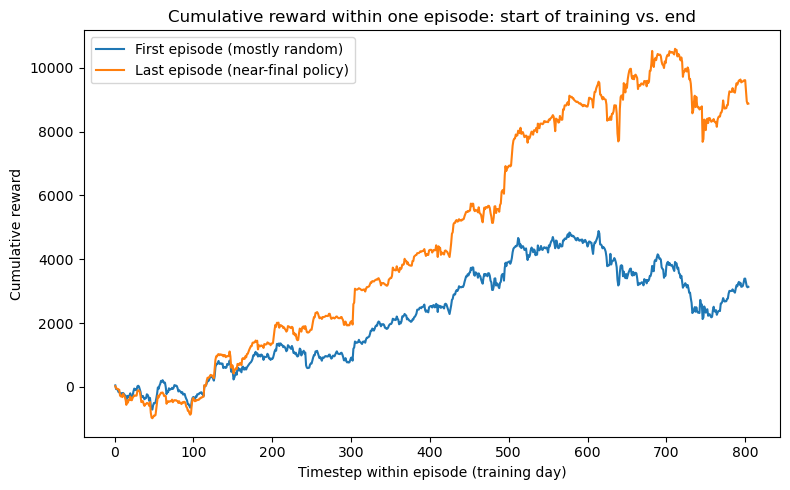

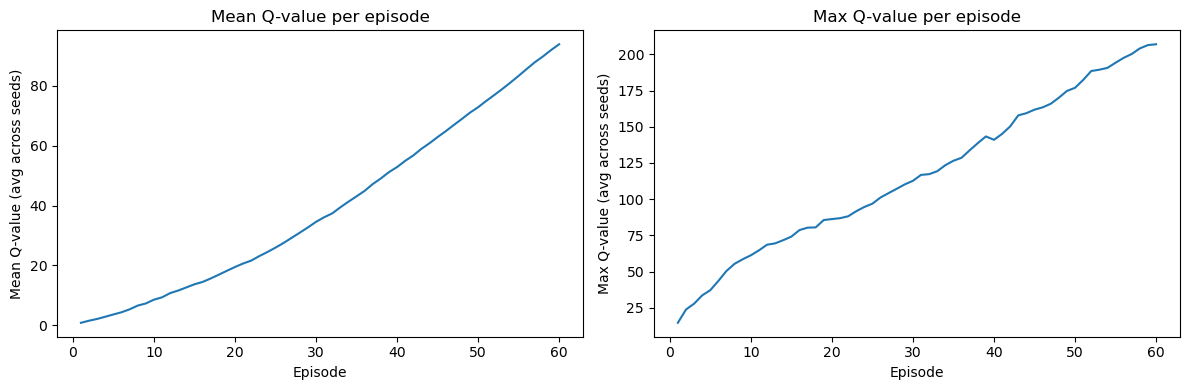

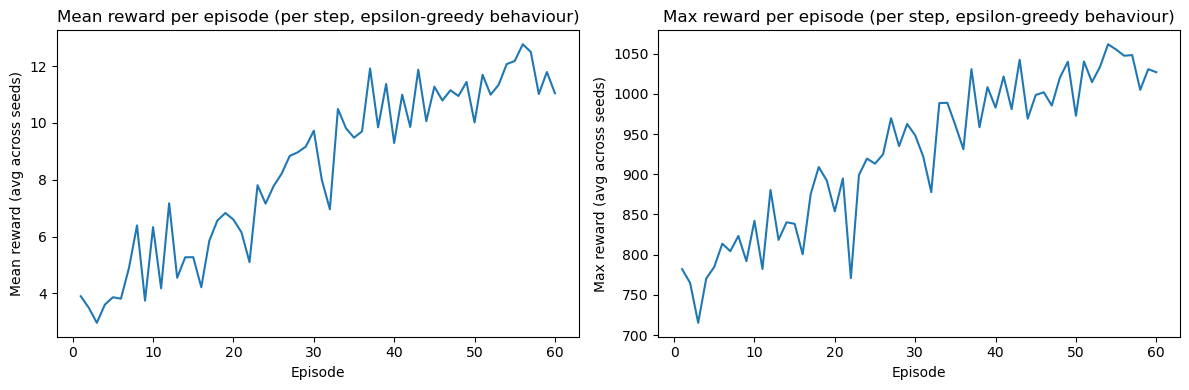


[Policy stability] States checked: 20/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 20 states -- mean: 85.2%  min: 55.0%  max: 100.0%

[State/action summary] 20/20 total states had >= 100 average visits across seeds
 state  avg_visits  majority_action  agreement_pct  mean_Q_majority_action
(9, 0)      4814.7                1           75.0                148.5562
(9, 1)      4545.3                1           95.0                117.7554
(0, 1)      4280.2                0           75.0                139.1765
(0, 0)      3339.8                1           70.0                134.5164
(1, 1)      2864.2                1           75.0                108.9870
(2, 1)      2807.4                1          100.0                122.2507
(8, 1)      2788.1                1           70.0                103.4674
(8, 0)      2311.9                0           95.0                113.7531
(1, 0)      2295.8

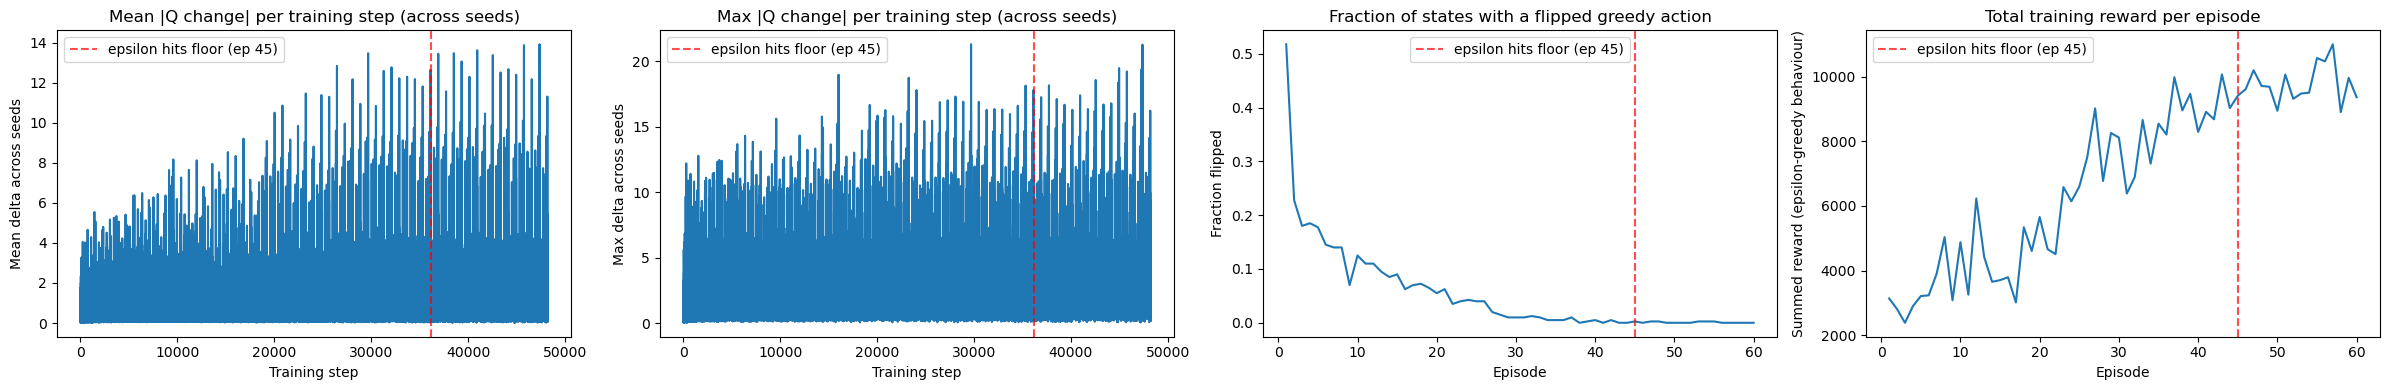

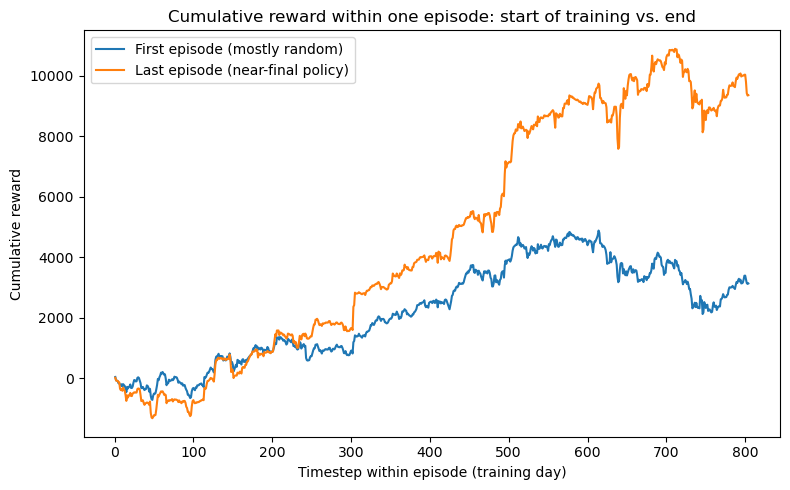

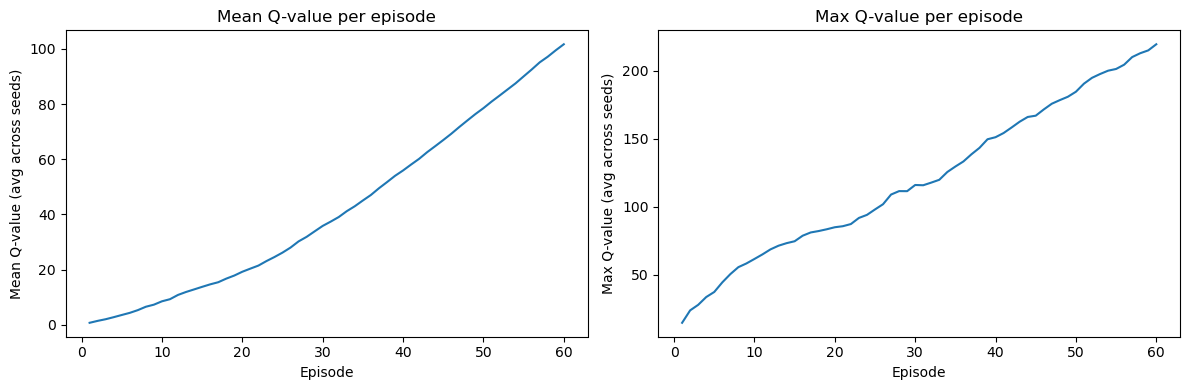

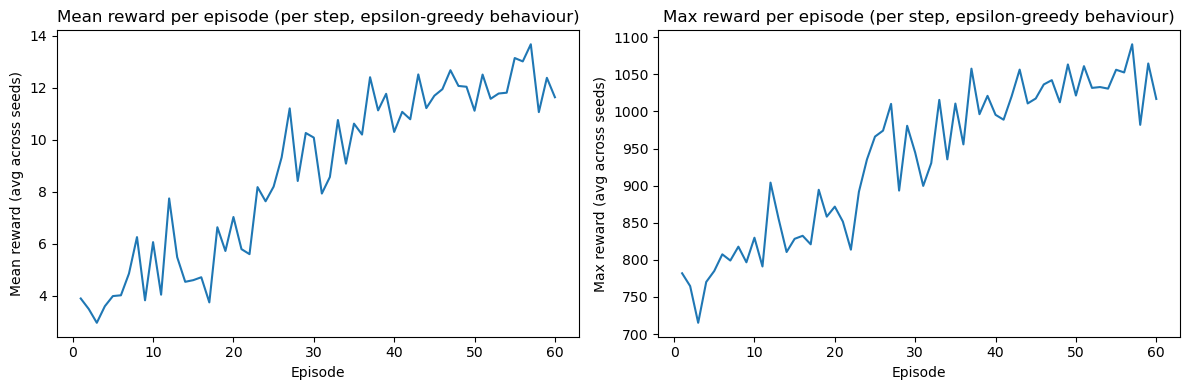


[Policy stability] States checked: 20/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 20 states -- mean: 85.8%  min: 60.0%  max: 100.0%

[State/action summary] 20/20 total states had >= 100 average visits across seeds
 state  avg_visits  majority_action  agreement_pct  mean_Q_majority_action
(9, 0)      4936.9                1           85.0                167.6057
(9, 1)      4423.1                1           95.0                130.0188
(0, 1)      4171.6                0           85.0                156.7327
(0, 0)      3448.3                1           75.0                145.2121
(1, 1)      2802.9                1           80.0                120.3052
(2, 1)      2746.7                1          100.0                135.2082
(8, 1)      2689.2                1           60.0                103.3493
(8, 0)      2410.8                0          100.0                129.7244
(1, 0)      2357.1

,eta,gamma,train_mean,train_std,val_mean,val_std
0,0.010,0.950,12434.3645,782.644344,10666.8290,897.978086
1,0.001,0.990,12817.9445,510.040813,10566.8250,601.721530
2,0.001,0.995,12824.9615,496.508332,10525.2705,645.029561
3,0.001,0.950,12824.9785,574.321393,10496.0995,648.789797
4,0.010,0.990,12588.4090,588.286442,10481.7760,903.720186
5,0.010,0.995,12664.3715,582.930552,10469.3325,775.641331


In [41]:
N = 20
episodes = 60
epsilon = 1.0
epsilon_decay = 0.95
epsilon_floor = 0.1
initial_cash = 10000
eta_grid = [0.001, 0.01]
gamma_grid = [0.95, 0.99, 0.995]
sarsa_search = grid_search_hyperparameters(train_and_evaluate_expected_sarsa, eta_grid, gamma_grid, N=N, episodes=episodes,
                                  epsilon_start=epsilon, epsilon_decay=epsilon_decay, epsilon_floor=epsilon_floor, run_diagnostics=True)
print("Expected SARSA -- best (eta, gamma):", tuple(sarsa_search.iloc[0][["eta", "gamma"]]))
sarsa_search

Hyperparameter tuning doesn't cause any substantial differences in the model i.e all the models seem to be relatively perform similarly with regard to hyperparameters. 

The low validation mean is more likely to be a byproduct of the time as oppposed to the actual model itself.

DIAGNOSTIC CHECKLIST
[Train/Test] Train -- mean: 12000.17  std: 247.21
[Train/Test] Test  -- mean: 12077.91  std: 659.50

[Coverage] Unvisited (state, action) pairs: 0 / 40 (0.0%)



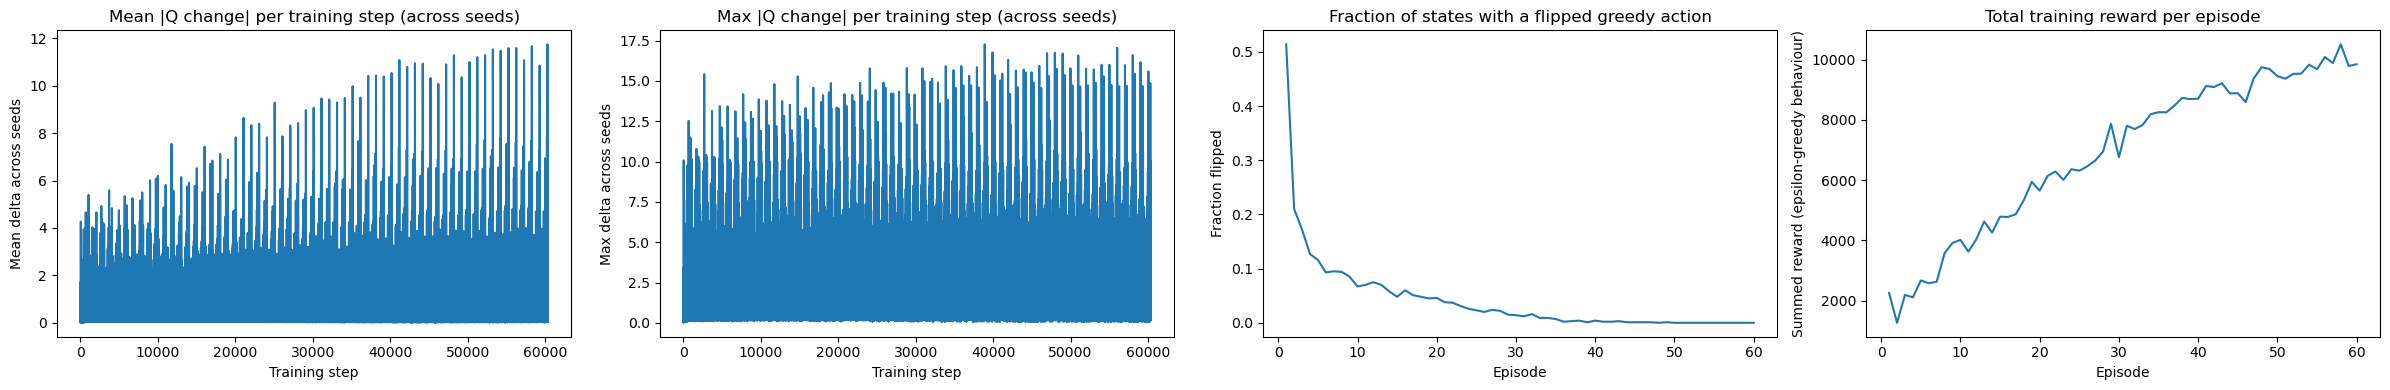

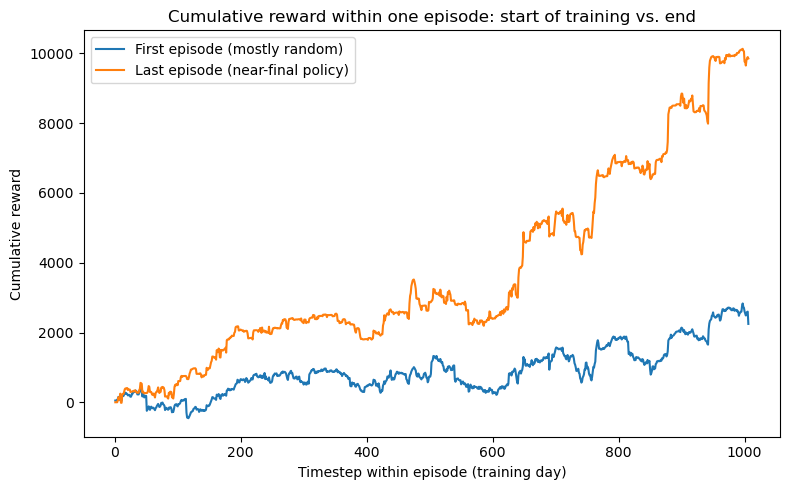

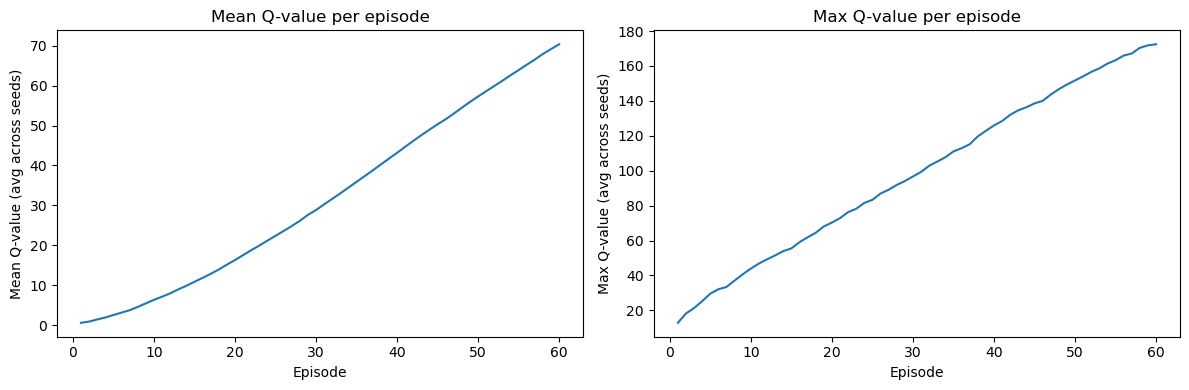

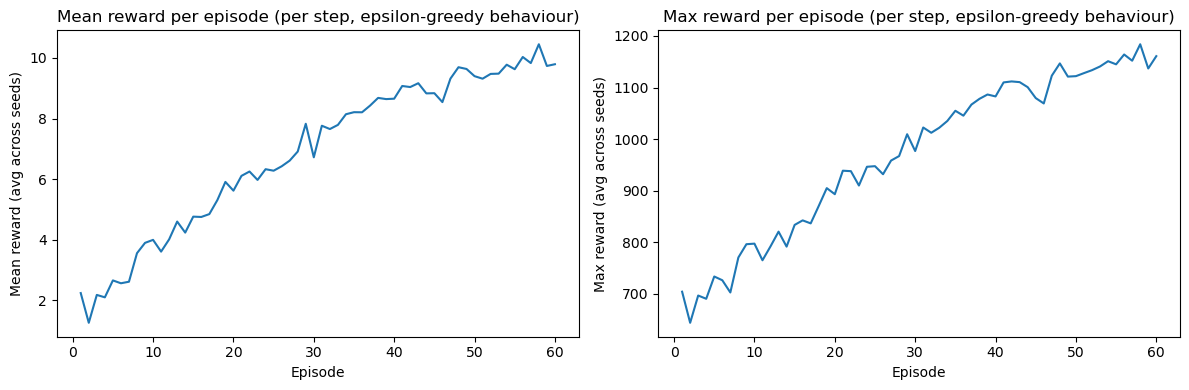


[Policy stability] States checked: 20/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 20 states -- mean: 92.3%  min: 52.0%  max: 100.0%

[State/action summary] 20/20 total states had >= 100 average visits across seeds
 state  avg_visits  majority_action  agreement_pct  mean_Q_majority_action
(0, 1)      3415.3                1           80.0                 74.9656
(9, 0)      3293.3                1          100.0                171.3085
(1, 1)      3286.0                0           66.0                 81.6765
(4, 1)      3283.5                1          100.0                 87.7329
(6, 1)      3177.9                1           98.0                 84.1943
(5, 1)      3109.0                1           96.0                 83.0984
(7, 1)      3089.2                0          100.0                127.8926
(8, 0)      3071.3                0           52.0                 63.0534
(2, 0)      3069.4

In [43]:
N = 50
episodes = 100
eta = 0.01
gamma = 0.9
epsilon = 1.0
epsilon_decay = 0.95
# change epsilon floor to 0 for final run for fully converged model
epsilon_floor = 0
initial_cash = 10000

best_eta_sarsa, best_gamma_sarsa = sarsa_search.iloc[0][["eta", "gamma"]]
best_sarsa = evaluate_best_hyperparameters(train_and_evaluate_expected_sarsa, best_eta_sarsa, best_gamma_sarsa)

run_full_diagnostics(
    visit_counts=best_sarsa["avg_visit_counts"],
    delta_history=best_sarsa["avg_delta_history_max"],
    delta_history_mean=best_sarsa["avg_delta_history_mean"],
    seed_agents=best_sarsa["seed_agents"],
    greedy_actions=best_sarsa["all_test_actions"],
    n_actions=n_actions,
    epsilon_start = best_sarsa["epsilon_start"],
    epsilon_decay = best_sarsa["epsilon_decay"],
    epsilon_floor = best_sarsa["epsilon_floor"],
    train_results = best_sarsa["train_results"],
    test_results = best_sarsa["test_results"],
    policy_flip_history=best_sarsa["avg_policy_flip_history"],
    episode_reward_history=best_sarsa["avg_episode_reward_history"],
    first_episode_reward_trace=best_sarsa["avg_first_episode_reward_trace"],
    last_episode_reward_trace=best_sarsa["avg_last_episode_reward_trace"],
    q_mean_history=best_sarsa["avg_Q_value_mean_history"],
    q_max_history=best_sarsa["avg_Q_value_max_history"],
    reward_mean_history=best_sarsa["avg_Reward_mean_history"],
    reward_max_history=best_sarsa["avg_Reward_max_history"],
)

This model seems to work better than the Q learning reinforcement learning model. It has the same issue with the Q values but works well otherwise. 

The next model to test is double Q learning

In [57]:
class Agent_double_q:
    def __init__(self, n_bins, n_cash_bins, n_actions=2, eta=0.1, gamma=0.95):
        self.Q_a = np.zeros((n_bins, n_cash_bins, n_actions))
        self.Q_b = np.zeros((n_bins, n_cash_bins, n_actions))
        self.visit_counts = np.zeros((n_bins, n_cash_bins, n_actions), dtype=int)  # for the coverage diagnostic
        self.eta = eta
        self.gamma = gamma

    # property is a wrapper to make agent_action work
    @property
    def Q(self):
        # combined estimate used for action selection, and for the diagnostics module
        # (coverage / policy stability / Q-gap checks all just read agent.Q)
        return (self.Q_a + self.Q_b) / 2

    def select_action(self, s):
        return np.argmax(self.Q[s])   # s is a (return_bin, cash_bin) tuple

    def update(self, s, s_next, a, r):
        # flip a coin to decide which table gets updated this step, using the OTHER table
        # to evaluate the chosen action - decouples action selection from value estimation
        if np.random.rand() < 0.5:
            a_star = np.argmax(self.Q_a[s_next])
            target = r + self.gamma * self.Q_b[s_next][a_star]
            self.Q_a[s][a] = self.Q_a[s][a] + self.eta * (target - self.Q_a[s][a])
        else:
            b_star = np.argmax(self.Q_b[s_next])
            target = r + self.gamma * self.Q_a[s_next][b_star]
            self.Q_b[s][a] = self.Q_b[s][a] + self.eta * (target - self.Q_b[s][a])
        self.visit_counts[s][a] += 1

For double Q-learning, the same general run structure (hyperparameters, then the initial run) is used, with a few diagnostics adjusted to account for the two tables:
- the Q-value mean/max trend uses the combined estimate `agent.Q = (Q_a + Q_b) / 2`, same as every other diagnostic that reads `agent.Q`
- a new gap trend tracks mean/max `|Q_a - Q_b|` per episode, to see whether the two tables are actually converging toward each other
- the policy-flip panel is split into two overlaid lines (one for Q_a's own greedy policy, one for Q_b's), since each table is only updated on roughly half the training steps (the coin-flip in `Agent_double_q.update`) and so can settle at a different rate

In [58]:
N = 50
episodes = 100
eta = 0.01
gamma = 0.95
epsilon = 1.0
epsilon_decay = 0.95
epsilon_floor = 0.1
initial_cash = 10000

In [59]:
def train_and_evaluate_double_q(seed, train_raw, test_raw, episodes=10, n_actions=2, eta=0.01, gamma=0.95,
                        epsilon_start=1.0, epsilon_decay=0.995, epsilon_floor=0.0, bin_edges=bin_edges,
                        cash_bin_edges=cash_bin_edges, n_bins=n_bins, n_cash_bins=n_cash_bins):
    np.random.seed(seed)

    agent = Agent_double_q(n_bins=n_bins, n_cash_bins=n_cash_bins, n_actions=n_actions, eta=eta, gamma=gamma)
    train_size = len(train_raw)
    epsilon = epsilon_start
    step_delta_history = []
    # tracked SEPARATELY per table, not combined -- Q_a and Q_b only get updated on roughly half
    # of the training steps each (the coin-flip in Agent_double_q.update), so they can converge at
    # different rates and a single combined-policy flip fraction would hide that
    policy_flip_history_a = []  # fraction of states whose Q_a-greedy action changed since the previous episode
    policy_flip_history_b = []  # fraction of states whose Q_b-greedy action changed since the previous episode
    episode_reward_history = []
    Q_mean = []
    # combined (Q_a + Q_b) / 2 magnitude, via the agent.Q property -- same meaning as the
    # single-table Q-learning/SARSA versions of these two lists
    Q_value_mean_history = []
    Q_value_max_history = []
    # how far apart the two tables' own estimates are, per episode -- NOT the same thing as the
    # combined magnitude above; a shrinking gap means the two tables are agreeing more over time
    Q_gap_mean_history = []
    Q_gap_max_history = []
    Reward_mean_history = []
    Reward_max_history = []
    first_episode_reward_trace = None
    last_episode_reward_trace = None
    first_episode_q_mean_trace = None
    first_episode_q_max_trace = None
    last_episode_q_mean_trace = None
    last_episode_q_max_trace = None

    for ep in range(episodes):
        Q_a_before = agent.Q_a.copy()
        Q_b_before = agent.Q_b.copy()
        state = State_basic(train_raw, uninvested_cash=initial_cash, n_bins=n_bins, bin_edges=bin_edges,
                             n_cash_bins=n_cash_bins, cash_bin_edges=cash_bin_edges)
        track_trace = (ep == 0) or (ep == episodes - 1)
        reward_trace = [] if track_trace else None
        q_mean_trace = [] if track_trace else None
        q_max_trace = [] if track_trace else None
        episode_reward_total = 0.0
        episode_reward_max = -np.inf
        for t in range(train_size - 1):
            s = state.get_observation(t)
            if np.random.rand() < epsilon:
                a = np.random.randint(agent.Q.shape[-1])
            else:
                a = agent.select_action(s)
            r = state.reward(a, t)
            episode_reward_total += r
            episode_reward_max = max(episode_reward_max, r)
            if track_trace:
                reward_trace.append(r)
            s_next = state.get_observation(t + 1)
            q_before_step = agent.Q[s][a]   # combined estimate, same bookkeeping as Q-learning/SARSA
            # agent.update() itself flips a coin each call to decide whether Q_a or Q_b gets
            # updated this step, using the OTHER table to evaluate the chosen action -- no
            # separate epsilon argument needed here, unlike Expected SARSA's update
            agent.update(s, s_next, a, r)
            step_delta_history.append(abs(agent.Q[s][a] - q_before_step))
            if track_trace:
                q_mean_trace.append(agent.Q.mean())
                q_max_trace.append(agent.Q.max())
        epsilon = max(epsilon * epsilon_decay, epsilon_floor)
        policy_before_a = np.argmax(Q_a_before, axis=-1)
        policy_after_a = np.argmax(agent.Q_a, axis=-1)
        policy_flip_history_a.append(np.mean(policy_before_a != policy_after_a))
        policy_before_b = np.argmax(Q_b_before, axis=-1)
        policy_after_b = np.argmax(agent.Q_b, axis=-1)
        policy_flip_history_b.append(np.mean(policy_before_b != policy_after_b))
        Q_mean.append(agent.Q.mean(axis=1).mean(axis=0))
        Q_value_mean_history.append(agent.Q.mean())
        Q_value_max_history.append(agent.Q.max())
        Q_gap_mean_history.append(np.abs(agent.Q_a - agent.Q_b).mean())
        Q_gap_max_history.append(np.abs(agent.Q_a - agent.Q_b).max())
        episode_reward_history.append(episode_reward_total)
        Reward_mean_history.append(episode_reward_total / (train_size - 1))
        Reward_max_history.append(episode_reward_max)
        if ep == 0:
            first_episode_reward_trace = reward_trace
            first_episode_q_mean_trace = q_mean_trace
            first_episode_q_max_trace = q_max_trace
        if ep == episodes - 1:
            last_episode_reward_trace = reward_trace
            last_episode_q_mean_trace = q_mean_trace
            last_episode_q_max_trace = q_max_trace

    train_final, train_actions = run_greedy(train_raw, agent, n_bins=n_bins, n_cash_bins=n_cash_bins)
    test_final, test_actions = run_greedy(test_raw, agent, n_bins=n_bins, n_cash_bins=n_cash_bins)

    return (agent, train_final, test_final, step_delta_history, train_actions, test_actions,
            Q_mean, policy_flip_history_a, policy_flip_history_b, episode_reward_history,
            first_episode_reward_trace, last_episode_reward_trace,
            Q_value_mean_history, Q_value_max_history, Q_gap_mean_history, Q_gap_max_history,
            Reward_mean_history, Reward_max_history,
            first_episode_q_mean_trace, first_episode_q_max_trace, last_episode_q_mean_trace, last_episode_q_max_trace)

In [60]:
train_results_double_q = np.zeros(N)
test_results_double_q = np.zeros(N)
seed_agents_double_q = []             # every seed's trained agent, for coverage / policy-stability diagnostics
all_step_delta_history_double_q = []  # every seed's per-training-step delta curve -- mean/max ACROSS SEEDS computed below
all_test_actions_double_q = []        # every seed's greedy test rollout, for the action-distribution diagnostic
all_policy_flip_history_a_double_q = []  # every seed's per-episode Q_a-greedy-action-flip fraction
all_policy_flip_history_b_double_q = []  # every seed's per-episode Q_b-greedy-action-flip fraction
all_episode_reward_history_double_q = []      # every seed's per-episode total training reward, averaged for the reward curve
all_first_episode_reward_trace_double_q = []  # every seed's episode-0 per-timestep reward trace, averaged for the within-episode plot
all_last_episode_reward_trace_double_q = []   # every seed's final-episode per-timestep reward trace, averaged for the within-episode plot
all_Q_value_mean_history_double_q = []  # every seed's per-episode mean combined-Q curve, averaged for the Q-value-magnitude plot
all_Q_value_max_history_double_q = []   # every seed's per-episode max combined-Q curve, averaged for the Q-value-magnitude plot
all_Q_gap_mean_history_double_q = []    # every seed's per-episode mean |Q_a - Q_b| curve, averaged for the gap-trend plot
all_Q_gap_max_history_double_q = []     # every seed's per-episode max |Q_a - Q_b| curve, averaged for the gap-trend plot
all_Reward_mean_history_double_q = []   # every seed's per-episode mean-reward-per-step curve, averaged for the reward-magnitude plot
all_Reward_max_history_double_q = []    # every seed's per-episode max-reward curve, averaged for the reward-magnitude plot
all_first_episode_q_mean_trace_double_q = []  # every seed's episode-0 per-timestep Q-mean trace, for the sanity-check plot
all_first_episode_q_max_trace_double_q = []   # every seed's episode-0 per-timestep Q-max trace, for the sanity-check plot
all_last_episode_q_mean_trace_double_q = []   # every seed's final-episode per-timestep Q-mean trace, for the sanity-check plot
all_last_episode_q_max_trace_double_q = []    # every seed's final-episode per-timestep Q-max trace, for the sanity-check plot
Q_mean_values_double_q = []
for seed in range(N):
    (agent, train_final, test_final, step_delta_history, train_actions, test_actions,
     Q_mean, policy_flip_history_a, policy_flip_history_b, episode_reward_history,
     first_episode_reward_trace, last_episode_reward_trace,
     Q_value_mean_history, Q_value_max_history, Q_gap_mean_history, Q_gap_max_history,
     Reward_mean_history, Reward_max_history,
     first_episode_q_mean_trace, first_episode_q_max_trace, last_episode_q_mean_trace, last_episode_q_max_trace) = train_and_evaluate_double_q(
        seed, train_raw, test_raw, episodes=episodes, n_bins=n_bins, n_actions=n_actions, eta=eta, gamma=gamma,
        epsilon_start=epsilon, epsilon_decay=epsilon_decay, epsilon_floor = epsilon_floor, bin_edges=bin_edges,
        n_cash_bins=n_cash_bins, cash_bin_edges=cash_bin_edges)
    train_results_double_q[seed] = train_final
    test_results_double_q[seed] = test_final
    seed_agents_double_q.append(agent)
    all_step_delta_history_double_q.append(step_delta_history)
    all_test_actions_double_q.append(test_actions)
    all_policy_flip_history_a_double_q.append(policy_flip_history_a)
    all_policy_flip_history_b_double_q.append(policy_flip_history_b)
    all_episode_reward_history_double_q.append(episode_reward_history)
    all_first_episode_reward_trace_double_q.append(first_episode_reward_trace)
    all_last_episode_reward_trace_double_q.append(last_episode_reward_trace)
    all_Q_value_mean_history_double_q.append(Q_value_mean_history)
    all_Q_value_max_history_double_q.append(Q_value_max_history)
    all_Q_gap_mean_history_double_q.append(Q_gap_mean_history)
    all_Q_gap_max_history_double_q.append(Q_gap_max_history)
    all_Reward_mean_history_double_q.append(Reward_mean_history)
    all_Reward_max_history_double_q.append(Reward_max_history)
    all_first_episode_q_mean_trace_double_q.append(first_episode_q_mean_trace)
    all_first_episode_q_max_trace_double_q.append(first_episode_q_max_trace)
    all_last_episode_q_mean_trace_double_q.append(last_episode_q_mean_trace)
    all_last_episode_q_max_trace_double_q.append(last_episode_q_max_trace)
    Q_mean_values_double_q.append(Q_mean)

avg_delta_history_mean_double_q = np.mean(all_step_delta_history_double_q, axis=0)  # mean across seeds, per training step
avg_delta_history_max_double_q = np.max(all_step_delta_history_double_q, axis=0)    # max across seeds, per training step
avg_policy_flip_history_a_double_q = np.mean(all_policy_flip_history_a_double_q, axis=0)
avg_policy_flip_history_b_double_q = np.mean(all_policy_flip_history_b_double_q, axis=0)
avg_episode_reward_history_double_q = np.mean(all_episode_reward_history_double_q, axis=0)
avg_first_episode_reward_trace_double_q = np.mean(all_first_episode_reward_trace_double_q, axis=0)
avg_last_episode_reward_trace_double_q = np.mean(all_last_episode_reward_trace_double_q, axis=0)
avg_Q_value_mean_history_double_q = np.mean(all_Q_value_mean_history_double_q, axis=0)
avg_Q_value_max_history_double_q = np.mean(all_Q_value_max_history_double_q, axis=0)
avg_Q_gap_mean_history_double_q = np.mean(all_Q_gap_mean_history_double_q, axis=0)
avg_Q_gap_max_history_double_q = np.mean(all_Q_gap_max_history_double_q, axis=0)
avg_Reward_mean_history_double_q = np.mean(all_Reward_mean_history_double_q, axis=0)
avg_Reward_max_history_double_q = np.mean(all_Reward_max_history_double_q, axis=0)
avg_first_episode_q_mean_trace_double_q = np.mean(all_first_episode_q_mean_trace_double_q, axis=0)
avg_first_episode_q_max_trace_double_q = np.mean(all_first_episode_q_max_trace_double_q, axis=0)
avg_last_episode_q_mean_trace_double_q = np.mean(all_last_episode_q_mean_trace_double_q, axis=0)
avg_last_episode_q_max_trace_double_q = np.mean(all_last_episode_q_max_trace_double_q, axis=0)
avg_Q_mean_double_q = np.mean(Q_mean_values_double_q, axis=0)
avg_visit_counts_double_q = np.mean([agent.visit_counts for agent in seed_agents_double_q], axis=0)

print(f"Episodes = {episodes}")
print(f"Double Q-learning (greedy) -- Train: mean={train_results_double_q.mean():.2f}, std={train_results_double_q.std():.2f}")
print(f"Double Q-learning (greedy) -- Test:  mean={test_results_double_q.mean():.2f}, std={test_results_double_q.std():.2f}")

Episodes = 100
Double Q-learning (greedy) -- Train: mean=12061.72, std=187.69
Double Q-learning (greedy) -- Test:  mean=12537.91, std=376.23


DIAGNOSTIC CHECKLIST
[Train/Test] Train -- mean: 12061.72  std: 187.69
[Train/Test] Test  -- mean: 12537.91  std: 376.23

[Coverage] Unvisited (state, action) pairs: 0 / 40 (0.0%)



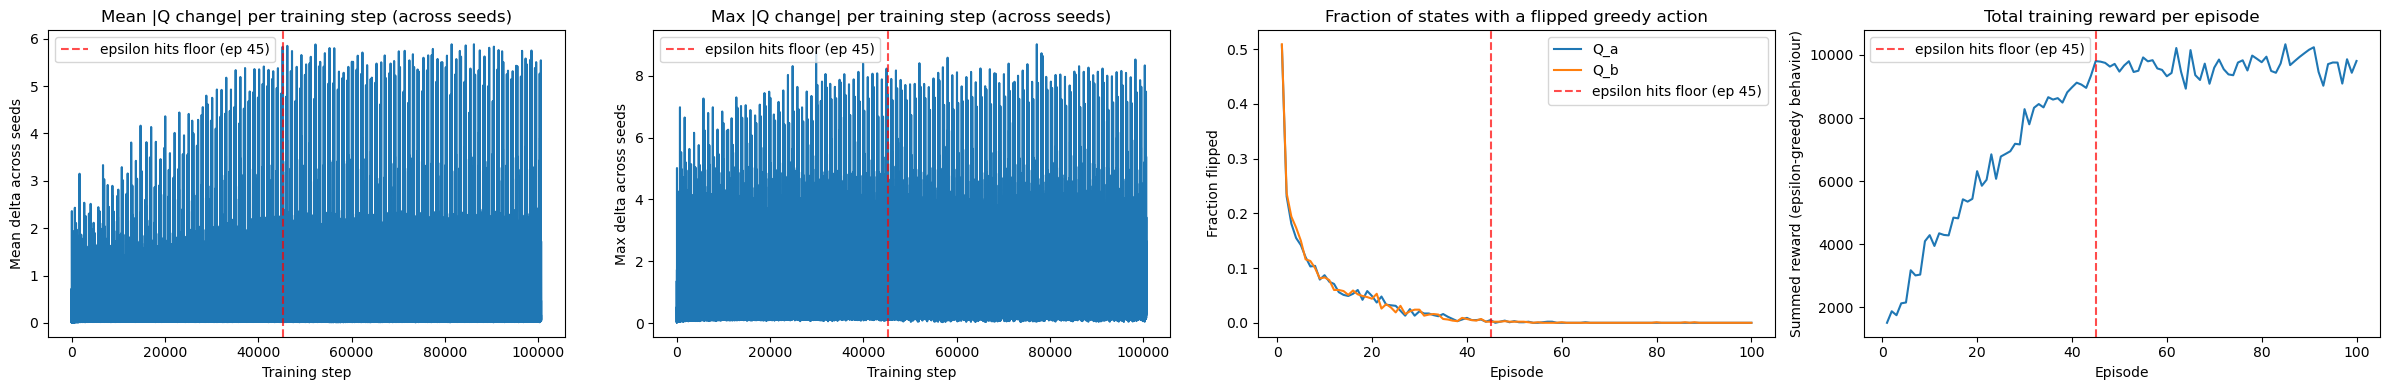

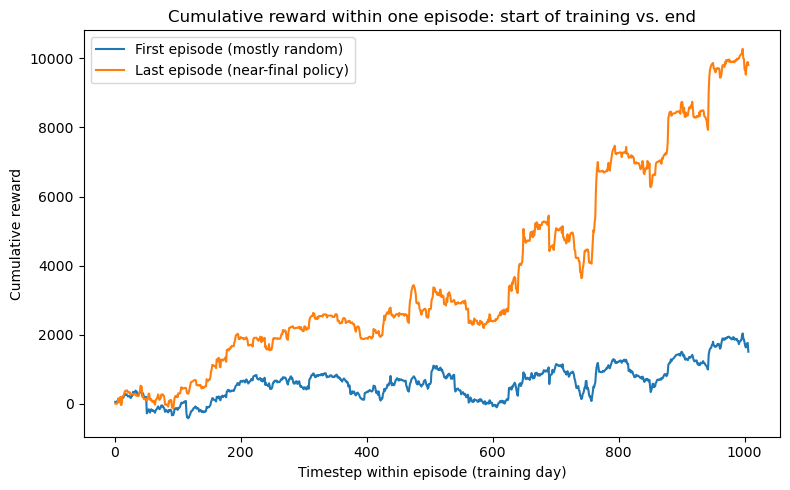

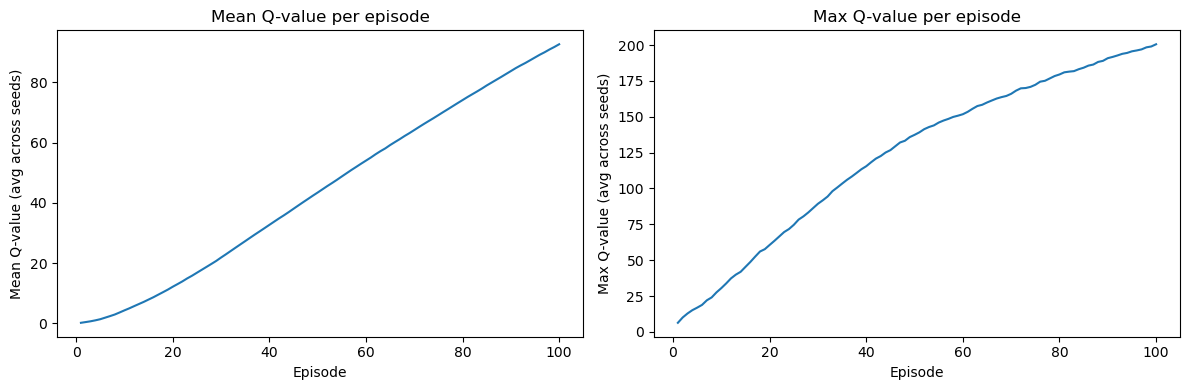

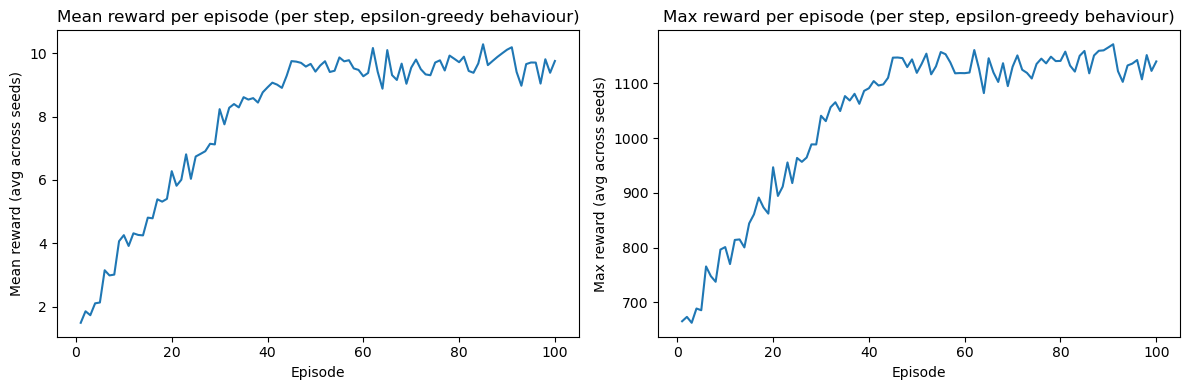

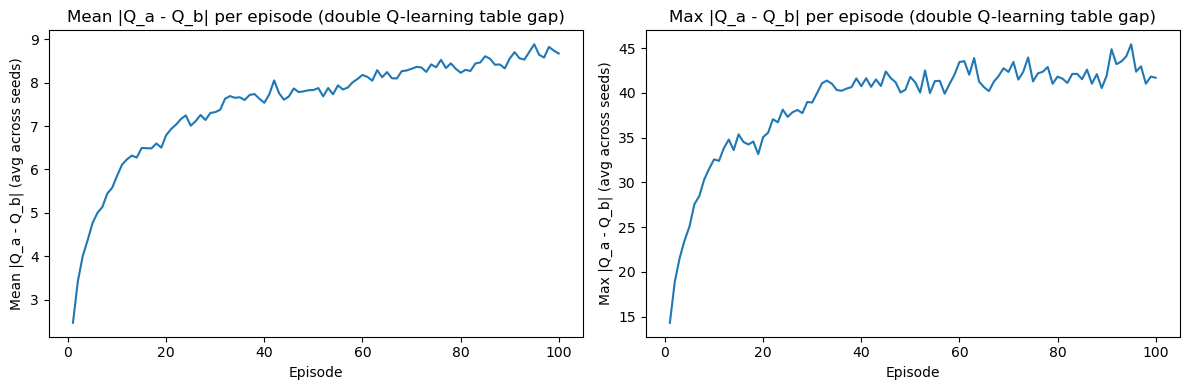


[Policy stability] States checked: 20/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 20 states -- mean: 91.5%  min: 56.0%  max: 100.0%

[State/action summary] 20/20 total states had >= 100 average visits across seeds
 state  avg_visits  majority_action  agreement_pct  mean_Q_majority_action
(9, 0)      6162.0                1          100.0                200.5688
(2, 0)      5848.6                1          100.0                174.2033
(8, 0)      5700.4                1           84.0                129.4945
(3, 0)      5604.8                1          100.0                151.2560
(7, 0)      5532.8                1          100.0                142.9222
(6, 0)      5524.8                0           90.0                109.4944
(5, 0)      5488.7                0          100.0                113.4675
(4, 0)      5308.7                0           92.0                110.9350
(0, 1)      5058.7

In [61]:
run_full_diagnostics(
    visit_counts=avg_visit_counts_double_q,
    delta_history=avg_delta_history_max_double_q,
    delta_history_mean=avg_delta_history_mean_double_q,
    seed_agents=seed_agents_double_q,
    greedy_actions=all_test_actions_double_q,
    n_actions=n_actions,
    epsilon_start=epsilon,
    epsilon_decay=epsilon_decay,
    epsilon_floor=epsilon_floor,
    train_results=train_results_double_q,
    test_results=test_results_double_q,
    policy_flip_history=avg_policy_flip_history_a_double_q,
    policy_flip_history_b=avg_policy_flip_history_b_double_q,
    episode_reward_history=avg_episode_reward_history_double_q,
    first_episode_reward_trace=avg_first_episode_reward_trace_double_q,
    last_episode_reward_trace=avg_last_episode_reward_trace_double_q,
    q_mean_history=avg_Q_value_mean_history_double_q,
    q_max_history=avg_Q_value_max_history_double_q,
    q_gap_mean_history=avg_Q_gap_mean_history_double_q,
    q_gap_max_history=avg_Q_gap_max_history_double_q,
    reward_mean_history=avg_Reward_mean_history_double_q,
    reward_max_history=avg_Reward_max_history_double_q,
)

In [66]:
from diagnostics import check_double_q_agreement
check_double_q_agreement(seed_agents_double_q)


[Double Q agreement] Seeds scored (had states with >= 100 visits): 50/50
[Double Q agreement] Mean |Q_a - Q_b| on well-sampled states -- mean: 8.6735  min: 5.7209  max: 12.3892
[Double Q agreement] Q_a vs Q_b greedy-action agreement -- mean: 100.0%  min: 100.0%  max: 100.0%


np.float64(1.0)

From the code, it is clear that the double Q values agree with each other on the appropriate action as well.

In [65]:
import pandas as pd

final_comparison_df
comparison_rows = {
    "Q-Learning": (best_q["train_results"], best_q["test_results"]),
    "Expected SARSA": (best_sarsa["train_results"], best_sarsa["test_results"]),
    "Double Q-Learning": (train_results_double_q, test_results_double_q),
    "Random Trading": (random_train_results, random_test_results),
    "Buy and Hold": (np.array([buy_hold_train]), np.array([buy_hold_test])),
}

final_comparison_df = pd.DataFrame({
    "Train": [fmt(train_vals) for train_vals, test_vals in comparison_rows.values()],
    "Test": [fmt(test_vals) for train_vals, test_vals in comparison_rows.values()],
}, index=list(comparison_rows.keys()))

final_comparison_df


,Train,Test
Q-Learning,11904.08 ± 218.68,12290.34 ± 443.99
Expected SARSA,12000.17 ± 247.21,12077.91 ± 659.50
Double Q-Learning,12061.72 ± 187.69,12537.91 ± 376.23
Random Trading,10463.92 ± 513.91,11345.57 ± 914.14
Buy and Hold,10640.31 ± 0.00,13110.34 ± 0.00
